In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau, spearmanr, pearsonr
import search_results_lib as srl
import json

In [3]:
# Colores llamativos (puedes cambiarlos)
HIGHLIGHT_COLORS = {
    "cuestionario-cpi": "#0072B2",          # azul
    "cpi-robertuito": "#D55E00",         # naranja
    "cpi-geo": "#CC79A7", # magenta
}
tops = [10, 20, 50, 100]

ignore=['index-index', 'ordenBusquedas', 'cuestionario_ordinal', 'cuestionario_no_common']
ignore_no_common = ['index-index', 'ordenBusquedas', 'cuestionario', 'cuestionario_ordinal']

thres = {
    'cuestionario': 0.6,
    'robertuito': 0,
    'bow': 0.6
}

thres_no_common = {
    'cuestionario_no_common': 0.6,
    'robertuito': 0,
    'bow': 0.6
}

segmentation=10

In [4]:
countries = [
    "Argentina",
    "Bolivia",
    "Chile",
    "Colombia",
    "Costa Rica",
    "Cuba",
    "Ecuador",
    "El Salvador",
    "Guatemala",
    "Honduras",
    "Mexico",
    "Nicaragua",
    "Panama",
    "Paraguay",
    "Peru",
    #"Puerto Rico",
    "Dominican Republic",
    "Uruguay",
    "Venezuela",
    "Spain"
]
n_countries = len(countries)
print(n_countries)  # 20
countries.sort()
df_dict = {}
corr_dict = {}

19


In [5]:
for i, country in enumerate(countries):
    print(f"{i+1}. {country}")

1. Argentina
2. Bolivia
3. Chile
4. Colombia
5. Costa Rica
6. Cuba
7. Dominican Republic
8. Ecuador
9. El Salvador
10. Guatemala
11. Honduras
12. Mexico
13. Nicaragua
14. Panama
15. Paraguay
16. Peru
17. Spain
18. Uruguay
19. Venezuela


## Caracteristicas con buena informacion mutua

In [5]:
def clean_features(features):
    import re
    return [
        re.sub(r"_(?:mean|std|cum|diff|delta_cum)_s\d+$", "", f)
        for f in features
    ]

fold_scores = pd.read_csv("clf_feature_scores_by_fold.csv")
feats_performance = fold_scores.groupby(['target', 'dataset', 'model', 'feature'])[['score', 'selected']].mean().reset_index().sort_values(['target', 'dataset', 'model', 'score'], ascending=[True, True, True, False])
bow_feats = list(feats_performance[feats_performance['dataset'] == 'bow'][feats_performance['selected'] >= 0.8]['feature'].unique())
forms_feats = list(feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8]['feature'].unique())

bow_clean_feats = list(set(clean_features(bow_feats)))
forms_clean_feats = list(set(clean_features(forms_feats)))

FileNotFoundError: [Errno 2] No such file or directory: 'clf_feature_scores_by_fold.csv'

In [6]:
bow_clean_feats = ["interesados", "figuran", "desarrollo social", "presentarse", "dades", "corrupción resultado", "circulación", "lacra", "rss", "inexistentes", "excepcional", "sobresueldos"]
forms_clean_feats = [
    "emociones__b",      # Tristeza
    "emociones__c",      # Ira
    "emociones__e",      # Sorpresa
    "intencion__c",      # Tomar acciones frente al problema (tomar acciones)
    "consecuencias__a",  # Penas o sanciones legales
    "consecuencias__c",  # Impunidad (falta de sanciones)
    "consecuencias__b",  # Consecuencias no legales (castigo social, pérdida de estatus)
    "involucrados__b",   # Gobierno nacional
    "involucrados__g",   # Tomadores de decisión no gubernamentales (líderes empresariales, activistas, etc.)
    "involucrados__h",   # Organizaciones internacionales o gobiernos extranjeros
    "tipo_entidad__c",   # Organismo internacional (ej. ONU)
    "localidad_problema__c",  # Regional (ej. América Latina)
]

In [52]:
top = 20

#feats_mi = pd.read_csv("../mi_results/mutual_information_top_per_dataset.csv")
feats_mi = pd.read_csv("../mi_results/mi_whole_dataset.csv", sep='\t', header=0)
ordered_feats_mi = feats_mi.groupby(['dataset', 'clean_feature']).mean()
ordered_feats_mi.sort_values('mutual_information', ascending=False, inplace=True)

bow_best_feats = ordered_feats_mi.loc['bow'].head(top).index.tolist()
forms_best_feats = ordered_feats_mi.loc['forms'].head(top).index.tolist()
robertuito_best_feats = ordered_feats_mi.loc['robertuito'].head(top).index.tolist()
'''
feats_mi = pd.read_csv("../mi_results/mutual_information_top_per_segment.csv")
ordered_feats_mi = feats_mi.groupby(['dataset', 'clean_feature', 'segment']).mean()
ordered_feats_mi.sort_values(['segment', 'mutual_information'], ascending=[True, False], inplace=True)
ordered_feats_mi.reset_index(inplace=True)

ordered_feats_mi[ordered_feats_mi['dataset'] == 'bow'].groupby('segment').head(top)

bow_best_feats = ordered_feats_mi[ordered_feats_mi['dataset'] == 'bow']['clean_feature'].unique().tolist()
bow_seg_feat_dict = {
    segment: ordered_feats_mi[(ordered_feats_mi['dataset'] == 'bow') & (ordered_feats_mi['segment'] == segment)].head(top)['clean_feature'].tolist()
    for segment in ordered_feats_mi['segment'].unique()
}
forms_best_feats = ordered_feats_mi[ordered_feats_mi['dataset'] == 'forms']['clean_feature'].unique().tolist()
forms_seg_feat_dict = {
    segment: ordered_feats_mi[(ordered_feats_mi['dataset'] == 'forms') & (ordered_feats_mi['segment'] == segment)].head(top)['clean_feature'].tolist()
    for segment in ordered_feats_mi['segment'].unique()
}
robertuito_best_feats = ordered_feats_mi[ordered_feats_mi['dataset'] == 'robertuito']['clean_feature'].unique().tolist()
robertuito_seg_feat_dict = {
    segment: ordered_feats_mi[(ordered_feats_mi['dataset'] == 'robertuito') & (ordered_feats_mi['segment'] == segment)].head(top)['clean_feature'].tolist()
    for segment in ordered_feats_mi['segment'].unique()
}

seg_feat_dict = {
    'bow': bow_seg_feat_dict,
    'cuestionario': forms_seg_feat_dict,
    'robertuito': robertuito_seg_feat_dict
}
'''

'\nfeats_mi = pd.read_csv("../mi_results/mutual_information_top_per_segment.csv")\nordered_feats_mi = feats_mi.groupby([\'dataset\', \'clean_feature\', \'segment\']).mean()\nordered_feats_mi.sort_values([\'segment\', \'mutual_information\'], ascending=[True, False], inplace=True)\nordered_feats_mi.reset_index(inplace=True)\n\nordered_feats_mi[ordered_feats_mi[\'dataset\'] == \'bow\'].groupby(\'segment\').head(top)\n\nbow_best_feats = ordered_feats_mi[ordered_feats_mi[\'dataset\'] == \'bow\'][\'clean_feature\'].unique().tolist()\nbow_seg_feat_dict = {\n    segment: ordered_feats_mi[(ordered_feats_mi[\'dataset\'] == \'bow\') & (ordered_feats_mi[\'segment\'] == segment)].head(top)[\'clean_feature\'].tolist()\n    for segment in ordered_feats_mi[\'segment\'].unique()\n}\nforms_best_feats = ordered_feats_mi[ordered_feats_mi[\'dataset\'] == \'forms\'][\'clean_feature\'].unique().tolist()\nforms_seg_feat_dict = {\n    segment: ordered_feats_mi[(ordered_feats_mi[\'dataset\'] == \'forms\') & (o

# Datos
## Indices de corrupcion

In [7]:
path = "../indices/datasets/CPI2024-Results-and-trends.csv"
df_index = pd.read_csv(path, header=2, encoding="ISO-8859-1", sep='\t')
df_index = df_index[df_index["Country / Territory"].isin(countries)]
df_index.dropna(how="all", axis=1, inplace=True)
df_index.rename(columns={"Country / Territory": "country"}, inplace=True)
df_index.set_index('country', inplace=True)

cpi2024_sources = {
    "rank": "Rank",
    "cpi": "CPI 2024 score",
    "gi": "S&P / Global Insights Country Risk Ratings",
    "prs": "PRS International Country Risk Guide",
    "vdem": "Varieties of Democracy Project",
    #"wef": "World Economic Forum EOS",
    "wjp": "World Justice Project Rule of Law cpi",
    "bti": "Bertelsmann Foundation Transformation cpi",
    "eiu": "Economist Intelligence Unit Country Ratings"
}
df_index.rename(columns=dict(zip(cpi2024_sources.values(), cpi2024_sources.keys())), inplace=True)

df_index.drop(columns=[i for i in df_index.columns if i not in cpi2024_sources.keys()], inplace=True)
df_index = df_index.reindex(countries)
df_index.dropna(how='all', inplace=True)
df_index.sort_index(inplace=True)
df_dict["cpi"] = df_index
df_index

,cpi,rank,eiu,gi,prs,vdem
country,,,,,,
Argentina,37,99,51.0,32.0,33.0,48.0
Bolivia,28,133,35.0,32.0,33.0,34.0
Chile,63,32,67.0,59.0,60.0,70.0
Colombia,39,92,51.0,46.0,33.0,48.0
Costa Rica,58,42,67.0,59.0,42.0,62.0
Cuba,41,82,51.0,32.0,49.0,35.0
Dominican Republic,36,104,51.0,32.0,24.0,32.0
Ecuador,32,121,35.0,32.0,33.0,30.0
El Salvador,30,130,35.0,32.0,33.0,27.0


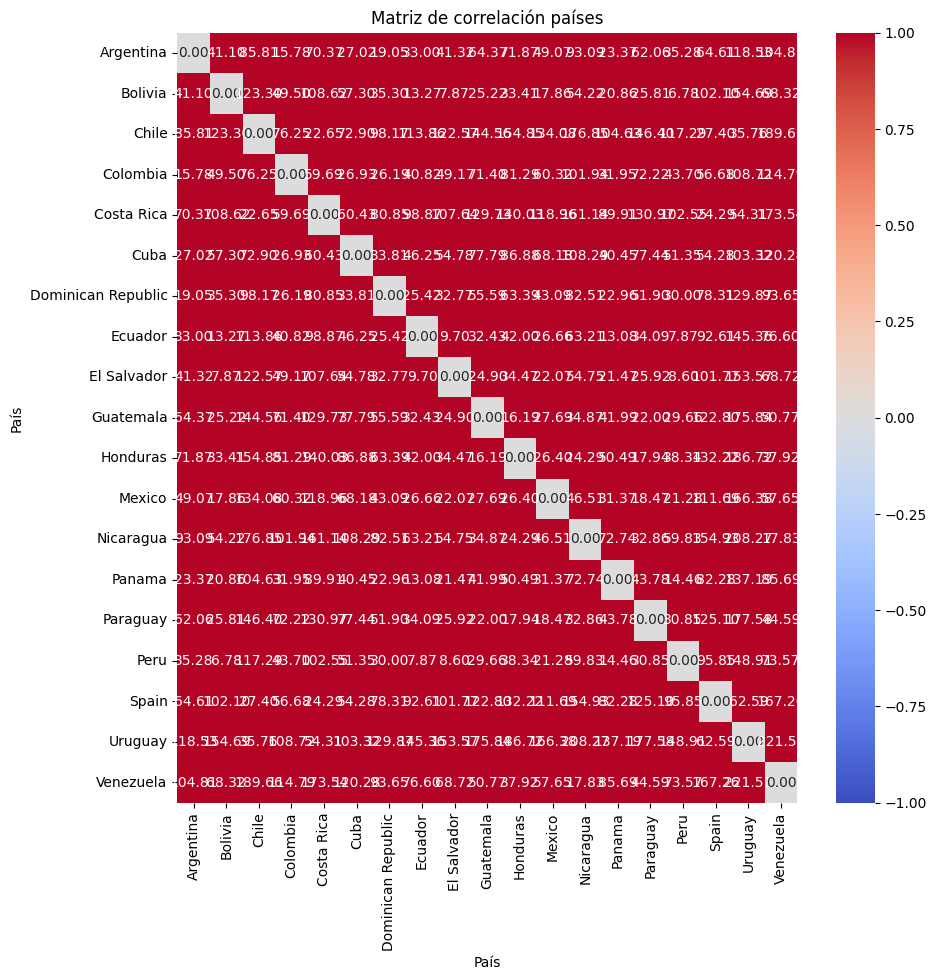

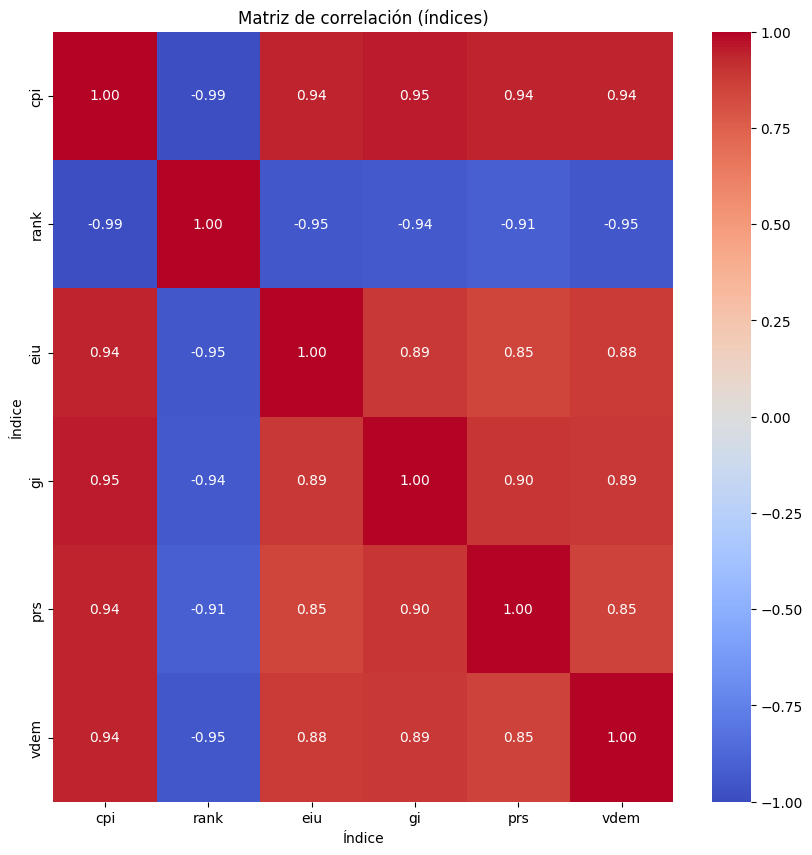

In [8]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

X = df_index.copy()

# Asegura numérico y limpia inf
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Imputa NaNs con mediana de cada columna
X_imp = X.fillna(X.median(numeric_only=True))

cpi = squareform(pdist(X_imp.values, metric="euclidean"))
corr_dict["cpi"] = pd.DataFrame(cpi, index=X_imp.index, columns=X_imp.index)

plt.figure(figsize=(10,10))
sns.heatmap(corr_dict['cpi'], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
#sns.heatmap(np.abs(index_corr), annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".1f")
plt.title("Matriz de correlación países")
plt.xlabel("País")
plt.ylabel("País")
plt.show()

#corrT = correlation(df_index.T)

corr_dict['index-index'] = df_index.corr()

plt.figure(figsize=(10,10))
#sns.heatmap(index_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
sns.heatmap(corr_dict['index-index'], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación (índices)")
plt.xlabel("Índice")
plt.ylabel("Índice")
plt.show()

## Rankings resultados de busqueda

In [9]:
# Leer el archivo JSON guardado
Nombre_Archivo = f"../buscador/resultados/resultados_corrupcion.json"

with open(Nombre_Archivo, "r") as file:
    resultados = json.load(file)
for i in range(len(resultados)):
    if resultados[i]['country'] == 'Puerto Rico':
        resultados.pop(i)
        break
resultados.sort(key=lambda x: x['country'])

# Leer el archivo JSON guardado
Nombre_Archivo = f"../buscador/resultados/res_unicos_corrupcion.json"

with open(Nombre_Archivo, "r") as file:
    all_hrefs = json.load(file)

max_len = max([len(r['search_results']['results']) for r in resultados])
rankings = {}
for r in resultados:
    pages = [all_hrefs.index(res['href']) for res in r['search_results']['results']]
    if len(pages) < max_len:
        diff = max_len - len(pages)
        pages += [np.nan] * diff
    rankings[r['country']] = pages
df_rankings = pd.DataFrame(rankings).T
df_rankings.sort_index(inplace=True)
df_dict["rankings"] = df_rankings
df_rankings

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Argentina,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,90.0,91.0,92.0,93.0,94.0,95.0,96.0,97.0,98.0,99.0
Bolivia,0.0,1.0,3.0,5.0,2.0,4.0,28.0,100.0,55.0,101.0,...,153.0,154.0,155.0,97.0,156.0,157.0,65.0,158.0,59.0,NaN
Chile,1.0,4.0,159.0,160.0,3.0,2.0,5.0,33.0,161.0,144.0,...,51.0,208.0,116.0,209.0,125.0,210.0,211.0,212.0,139.0,82.0
Colombia,0.0,1.0,3.0,2.0,4.0,5.0,28.0,8.0,119.0,43.0,...,266.0,75.0,144.0,132.0,124.0,146.0,267.0,131.0,86.0,268.0
Costa Rica,1.0,3.0,2.0,4.0,5.0,158.0,28.0,269.0,270.0,271.0,...,137.0,59.0,82.0,125.0,155.0,298.0,299.0,300.0,NaN,NaN
Cuba,0.0,1.0,2.0,3.0,4.0,5.0,28.0,55.0,43.0,8.0,...,315.0,30.0,299.0,141.0,153.0,316.0,32.0,101.0,NaN,NaN
Dominican Republic,0.0,1.0,3.0,2.0,4.0,5.0,106.0,120.0,28.0,527.0,...,300.0,475.0,79.0,361.0,127.0,344.0,143.0,155.0,31.0,312.0
Ecuador,1.0,3.0,159.0,5.0,317.0,2.0,4.0,63.0,318.0,319.0,...,68.0,136.0,353.0,96.0,138.0,58.0,153.0,NaN,NaN,NaN
El Salvador,0.0,1.0,2.0,3.0,4.0,5.0,28.0,354.0,55.0,43.0,...,143.0,158.0,138.0,140.0,209.0,53.0,314.0,77.0,362.0,203.0
EspaÃ±a,1.0,159.0,4.0,2.0,3.0,33.0,5.0,563.0,87.0,8.0,...,348.0,307.0,123.0,65.0,594.0,595.0,18.0,86.0,596.0,12.0


## Matriz de distancia entre capitales

In [10]:
capital_coords = {
    "Argentina": (-34.6037, -58.3816),            # Buenos Aires
    "Bolivia": (-16.4897, -68.1193),              # La Paz (sede de gobierno)
    "Chile": (-33.4489, -70.6693),                 # Santiago
    "Colombia": (4.7110, -74.0721),                # Bogotá
    "Costa Rica": (9.9281, -84.0907),              # San José
    "Cuba": (23.1136, -82.3666),                   # La Habana
    "Ecuador": (-0.1807, -78.4678),                # Quito
    "El Salvador": (13.6929, -89.2182),            # San Salvador
    "Guatemala": (14.6349, -90.5061),              # Ciudad de Guatemala
    "Honduras": (14.0723, -87.1921),               # Tegucigalpa
    "Mexico": (19.4326, -99.1332),                 # Ciudad de México
    "Nicaragua": (12.1140, -86.2362),              # Managua
    "Panama": (8.9824, -79.5199),                  # Ciudad de Panamá
    "Paraguay": (-25.2637, -57.5759),              # Asunción
    "Peru": (-12.0464, -77.0428),                  # Lima
    #"Puerto Rico": (18.4655, -66.1057),            # San Juan
    "Dominican Republic": (18.4861, -69.9312),     # Santo Domingo
    "Uruguay": (-34.9011, -56.1645),               # Montevideo
    "Venezuela": (10.4806, -66.9036),              # Caracas
    "Spain": (40.4168, -3.7038)                    # Madrid
}

D = np.zeros((n_countries, n_countries), dtype=float)

for i, ci in enumerate(countries):
    for j, cj in enumerate(countries):
        if i == j:
            D[i, j] = 0.0
        else:
            D[i, j] = srl.haversine_km(capital_coords[ci], capital_coords[cj])

# DataFrame cuadrado país x país (normalizado 0..1)
corr_dict['geo'] = pd.DataFrame(D/D.max(), index=countries, columns=countries)
corr_dict['geo']

,Argentina,Bolivia,Chile,Colombia,Costa Rica,Cuba,Dominican Republic,Ecuador,El Salvador,Guatemala,Honduras,Mexico,Nicaragua,Panama,Paraguay,Peru,Spain,Uruguay,Venezuela
Argentina,0.000000,0.208884,0.106421,0.436413,0.527375,0.644683,0.563288,0.407404,0.586834,0.601879,0.580192,0.690724,0.557697,0.498319,0.097313,0.293159,0.938599,0.019177,0.475894
Bolivia,0.208884,0.000000,0.177817,0.228609,0.319833,0.436198,0.363872,0.199874,0.381119,0.396643,0.373023,0.489514,0.350660,0.289447,0.136945,0.100993,0.856755,0.221200,0.280501
Chile,0.106421,0.177817,0.000000,0.397893,0.469823,0.598986,0.539656,0.353945,0.523156,0.536891,0.520194,0.617647,0.497864,0.449454,0.145706,0.230461,1.000000,0.125480,0.457947
Colombia,0.436413,0.228609,0.397893,0.000000,0.116575,0.208529,0.149168,0.068297,0.181062,0.197184,0.165838,0.296273,0.146708,0.071599,0.353145,0.176794,0.748609,0.447272,0.095074
Costa Rica,0.527375,0.319833,0.469823,0.116575,0.000000,0.138064,0.167913,0.120046,0.065178,0.081429,0.053357,0.180385,0.031536,0.047864,0.453559,0.239630,0.792649,0.540678,0.175822
Cuba,0.644683,0.436198,0.598986,0.208529,0.138064,0.000000,0.129930,0.245213,0.118866,0.118942,0.105244,0.166666,0.120515,0.149533,0.561219,0.369306,0.695206,0.655775,0.201867
Dominican Republic,0.563288,0.363872,0.539656,0.149168,0.167913,0.129930,0.000000,0.212627,0.198743,0.208640,0.178053,0.286779,0.176177,0.138166,0.471416,0.325498,0.625708,0.571101,0.088568
Ecuador,0.407404,0.199874,0.353945,0.068297,0.120046,0.245213,0.212627,0.000000,0.181711,0.197489,0.173156,0.293000,0.150787,0.095825,0.334509,0.124158,0.816429,0.420632,0.162935
El Salvador,0.586834,0.381119,0.523156,0.181062,0.065178,0.118866,0.198743,0.181711,0.000000,0.016252,0.020813,0.115301,0.034367,0.110225,0.516219,0.295380,0.808345,0.600858,0.229057
Guatemala,0.601879,0.396643,0.536891,0.197184,0.081429,0.118942,0.208640,0.197489,0.016252,0.000000,0.033866,0.099113,0.050483,0.126174,0.531976,0.309924,0.812255,0.616056,0.243085


## Evaluaciones de cuestionario

In [12]:
df_responses = pd.read_csv("../buscador/responses_llama.csv", sep='\t', header=0)

multi_choice = ['proposito',
                'informacion_presentada',
                'consecuencias',
                'intencion',
                'localidad_problema',
                'involucrados',
                'emociones']

possible_answers = {"tipo_entidad": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'],
                    "origen_entidad": ['a', 'b'],
                    "vision": ['a', 'b', 'c', 'd'],
                    'que_muestra': ['a', 'b', 'c', 'd'],
                    'formalidad': ['a', 'b'],
                    'nivel_educacion': ['a', 'b'],
                    'tono': ['a', 'b'],
                    "proposito": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'],
                    "informacion_presentada": ['a', 'b', 'c'],
                    "consecuencias": ['a', 'b', 'c', 'd'],
                    "intencion": ['a', 'b', 'c', 'd', 'e', 'f'],
                    "localidad_problema": ['a', 'b', 'c'],
                    "involucrados": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'],
                    "emociones": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
                    }
single_questions = [q for q in possible_answers if q not in multi_choice]

# humano < 75% precision llama < 0.6
#bad_questions = ['proposito__d', 'tono', 'intencion__c', 'que_muestra', 'proposito__g', 'consecuencias__c', 'proposito__b', 'emociones__h', 'formalidad', 'localidad_problema__a']
bad_questions = ['proposito__d', 'tono', 'que_muestra', 'proposito__g', 'proposito__b', 'emociones__h', 'formalidad']
# humano < 75% precision llama <= 0.6
#bad_questions = ['proposito__d', 'tono', 'intencion__c', 'que_muestra', 'proposito__g', 'consecuencias__c', 'proposito__b', 'involucrados__f', 'origen_entidad', 'intencion__b', 'emociones__h', 'vision', 'intencion__a', 'formalidad', 'involucrados__b', 'tipo_entidad', 'localidad_problema__a', 'localidad_problema__b']
#bad_questions.remove('emociones__h') # se elimina emocion neutral
for q in bad_questions:
    if "__" not in q:
        for i in possible_answers.get(q, []):
            bad_questions.append(f"{q}__{i}")
bad_questions = [bad for bad in bad_questions if "__" in bad]

df_pag_info = srl.analyze_pages(df_responses, multi_choice, possible_answers)
df_pag_info = df_pag_info.drop(columns=bad_questions)
one_hot_cols = [col for col in df_pag_info.columns if df_pag_info[col].isin([0, 1]).all()]
df_pag_info_ordinal = srl.analyze_pages(df_responses, multi_choice, possible_answers, ordinal=True)
df_pag_info_ordinal = df_pag_info_ordinal.drop(columns=bad_questions)
#df_dict["cuestionario"] = df_pag_info[forms_best_feats]
df_dict["cuestionario"] = df_pag_info[forms_clean_feats]
#df_dict["cuestionario_ordinal"] = df_pag_info_ordinal

df_dict['cuestionario']

,emociones__b,emociones__c,emociones__e,intencion__c,consecuencias__a,consecuencias__c,consecuencias__b,involucrados__b,involucrados__g,involucrados__h,tipo_entidad__c,localidad_problema__c
pagina,,,,,,,,,,,,
0,0.0,0.0,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0,1.000000
1,0.0,0.0,0.333333,0.333333,0.666667,0.333333,0.000000,0.000000,0.000000,0.000000,0,0.333333
2,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
3,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.333333,1,0.000000
4,0.0,0.0,0.333333,0.000000,0.000000,0.000000,1.000000,0.333333,0.333333,0.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
592,0.0,0.0,0.333333,0.000000,0.000000,1.000000,0.000000,0.333333,0.000000,0.000000,0,0.666667
593,0.0,0.0,0.000000,0.333333,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0,0.333333
594,0.0,0.0,0.000000,0.333333,0.666667,0.000000,0.000000,0.000000,0.000000,0.333333,0,0.333333


In [122]:
df_dict["cuestionario"]

,nivel_educacion__a,nivel_educacion__b,origen_entidad__a,origen_entidad__b,tipo_entidad__a,tipo_entidad__b,tipo_entidad__c,tipo_entidad__d,tipo_entidad__e,tipo_entidad__f,...,involucrados__f,involucrados__g,involucrados__h,emociones__a,emociones__b,emociones__c,emociones__d,emociones__e,emociones__f,emociones__g
pagina,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.333333,0.000000,0.000000
2,0,1,0,1,0,0,0,0,0,0,...,0.666667,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.000000
3,0,1,0,1,0,0,1,0,0,0,...,0.333333,0.000000,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,0,1,0,1,0,0,0,0,0,0,...,1.000000,0.333333,0.000000,0.0,0.0,0.0,0.333333,0.333333,0.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,0,1,1,0,0,0,0,1,0,0,...,0.333333,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.333333,0.000000,0.333333
593,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.333333
594,0,1,1,0,0,1,0,0,0,0,...,0.666667,0.000000,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.666667


In [123]:
Nombre_Archivo = f"./buscador/resultados/resultados_corrupcion.json"
with open(Nombre_Archivo, "r") as file:
    resultados = json.load(file)
common = srl.get_common(resultados, top=100)
idx = [all_hrefs.index(c) for c in common]

Nombre_Archivo = f"./buscador/resultados/res_unicos_corrupcion.json"
with open(Nombre_Archivo, "r") as file:
    all_hrefs = json.load(file)

df_dict['cuestionario_no_common'] = df_pag_info.drop(index=idx)

In [124]:
df_dict['cuestionario_no_common']

,nivel_educacion__a,nivel_educacion__b,origen_entidad__a,origen_entidad__b,tipo_entidad__a,tipo_entidad__b,tipo_entidad__c,tipo_entidad__d,tipo_entidad__e,tipo_entidad__f,...,involucrados__f,involucrados__g,involucrados__h,emociones__a,emociones__b,emociones__c,emociones__d,emociones__e,emociones__f,emociones__g
pagina,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0,1,1,0,0,1,0,0,0,0,...,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.333333
7,0,1,1,0,0,1,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000
8,0,1,0,1,0,0,1,0,0,0,...,0.000000,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000
9,1,0,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.666667,0.666667,0.333333,0.666667,0.666667,0.333333,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,0,1,1,0,0,0,0,1,0,0,...,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.333333
593,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333
594,0,1,1,0,0,1,0,0,0,0,...,0.666667,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.666667


## Robertuito

In [13]:
bad_labels = ['emotion__others', 'sentiment__NEU', 'irony__not ironic']
df_robertuito = pd.read_csv("../buscador/robertuito/robertuito_all_results.csv").drop(columns=bad_labels)
df_robertuito.set_index('pagina', inplace=True)
df_dict["robertuito"] = df_robertuito#[robertuito_best_feats]
df_robertuito

,emotion__joy,emotion__sadness,emotion__anger,emotion__fear,emotion__surprise,emotion__disgust,sentiment__NEG,sentiment__POS,hate__speech__hateful,hate__speech__targeted,hate__speech__aggressive,irony__ironic
pagina,,,,,,,,,,,,
12,0.00,0.02,0.75,0.0,0.01,0.09,0.84,0.01,0.04,0.01,0.02,0.00
571,0.00,0.00,0.00,0.0,0.00,0.00,0.09,0.05,0.03,0.01,0.02,0.13
200,0.00,0.00,0.00,0.0,0.00,0.00,0.07,0.12,0.02,0.01,0.01,0.01
394,0.00,0.00,0.00,0.0,0.00,0.00,0.07,0.15,0.02,0.01,0.02,0.01
397,0.00,0.01,0.04,0.0,0.00,0.00,0.65,0.03,0.03,0.01,0.03,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.01,0.00,0.00,0.0,0.00,0.00,0.10,0.14,0.02,0.01,0.01,0.08
9,0.00,0.00,0.00,0.0,0.00,0.00,0.17,0.09,0.02,0.00,0.01,0.00
575,0.00,0.01,0.64,0.0,0.00,0.05,0.32,0.03,0.02,0.00,0.02,0.01


## BOW

In [14]:
df_dict['bow'] = pd.read_csv('../bow_pags_corrupcion.csv')
df_dict['bow'].index.name = 'pagina'
#bow_cols_valid = [col for col in bow_best_feats if col in df_dict['bow'].columns]
bow_cols_valid = [col for col in bow_clean_feats if col in df_dict['bow'].columns]
df_dict['bow'] = df_dict['bow'][bow_cols_valid]
df_dict['bow']

,interesados,figuran,desarrollo social,presentarse,dades,corrupción resultado,circulación,lacra,rss,inexistentes,excepcional,sobresueldos
pagina,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,1,0,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
546,0,0,0,0,0,0,0,0,0,0,0,0
547,1,0,1,0,0,0,1,0,0,1,1,0
548,0,0,0,0,0,0,0,1,0,0,0,0


# Analisis con caracteristicas mas relevantes

## Binarias
### Todas las caracteristicas

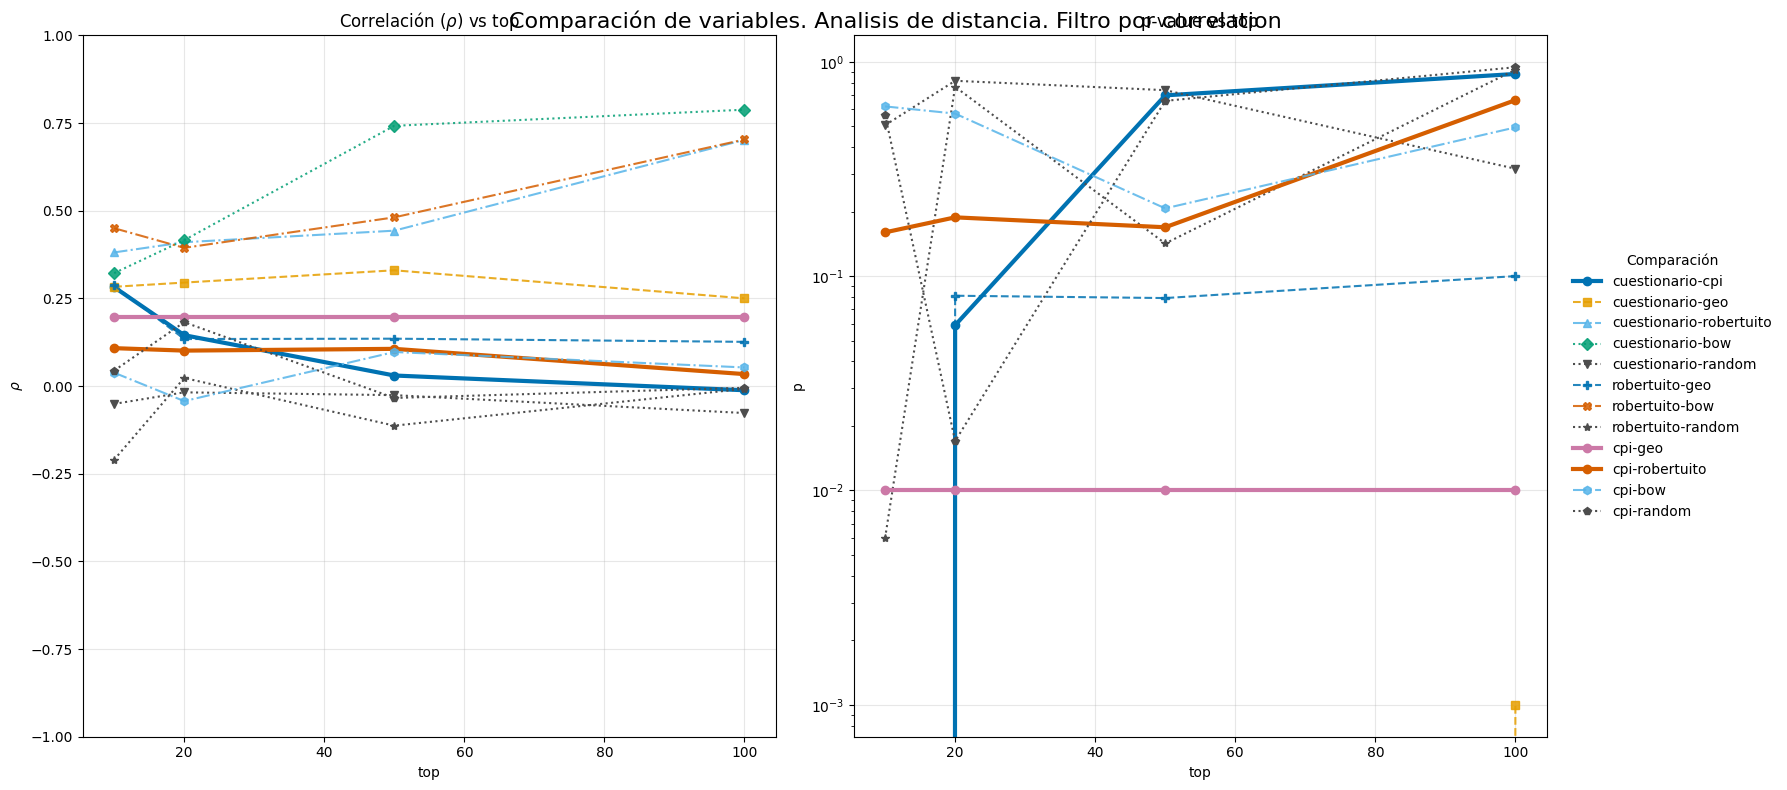

In [ ]:
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='distance',
    keys=thres.keys(),
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

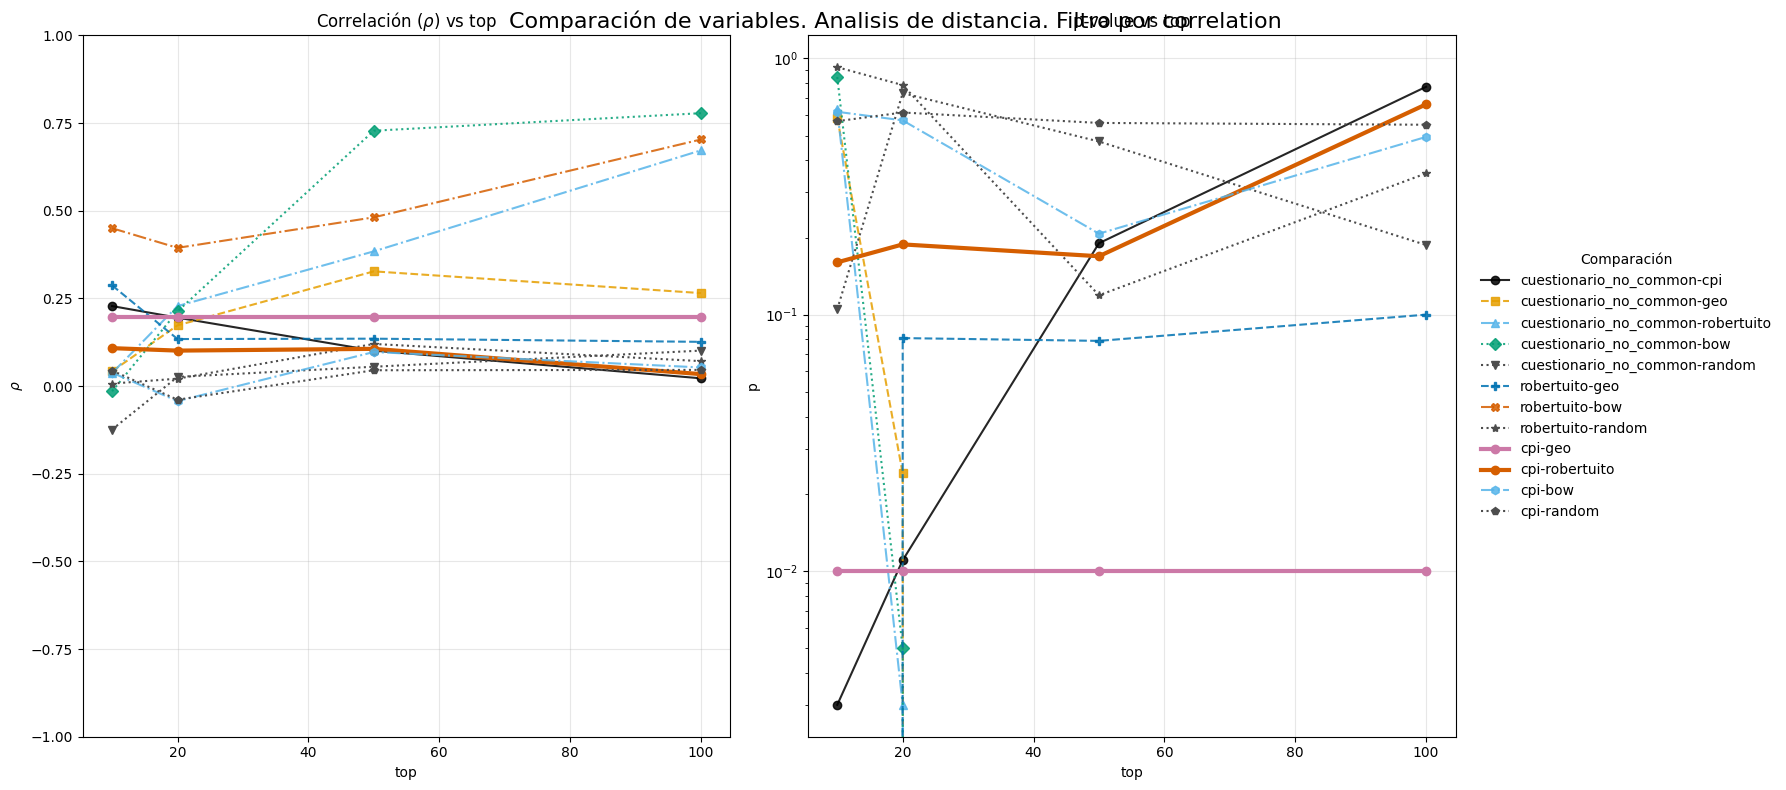

In [ ]:
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='distance',
    keys=thres_no_common.keys(),
    ignore=ignore_no_common, 
    segmentation=segmentation, 
    one_hot_cols=one_hot_cols, 
    expanded=True,
    suffix='_no_common',
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

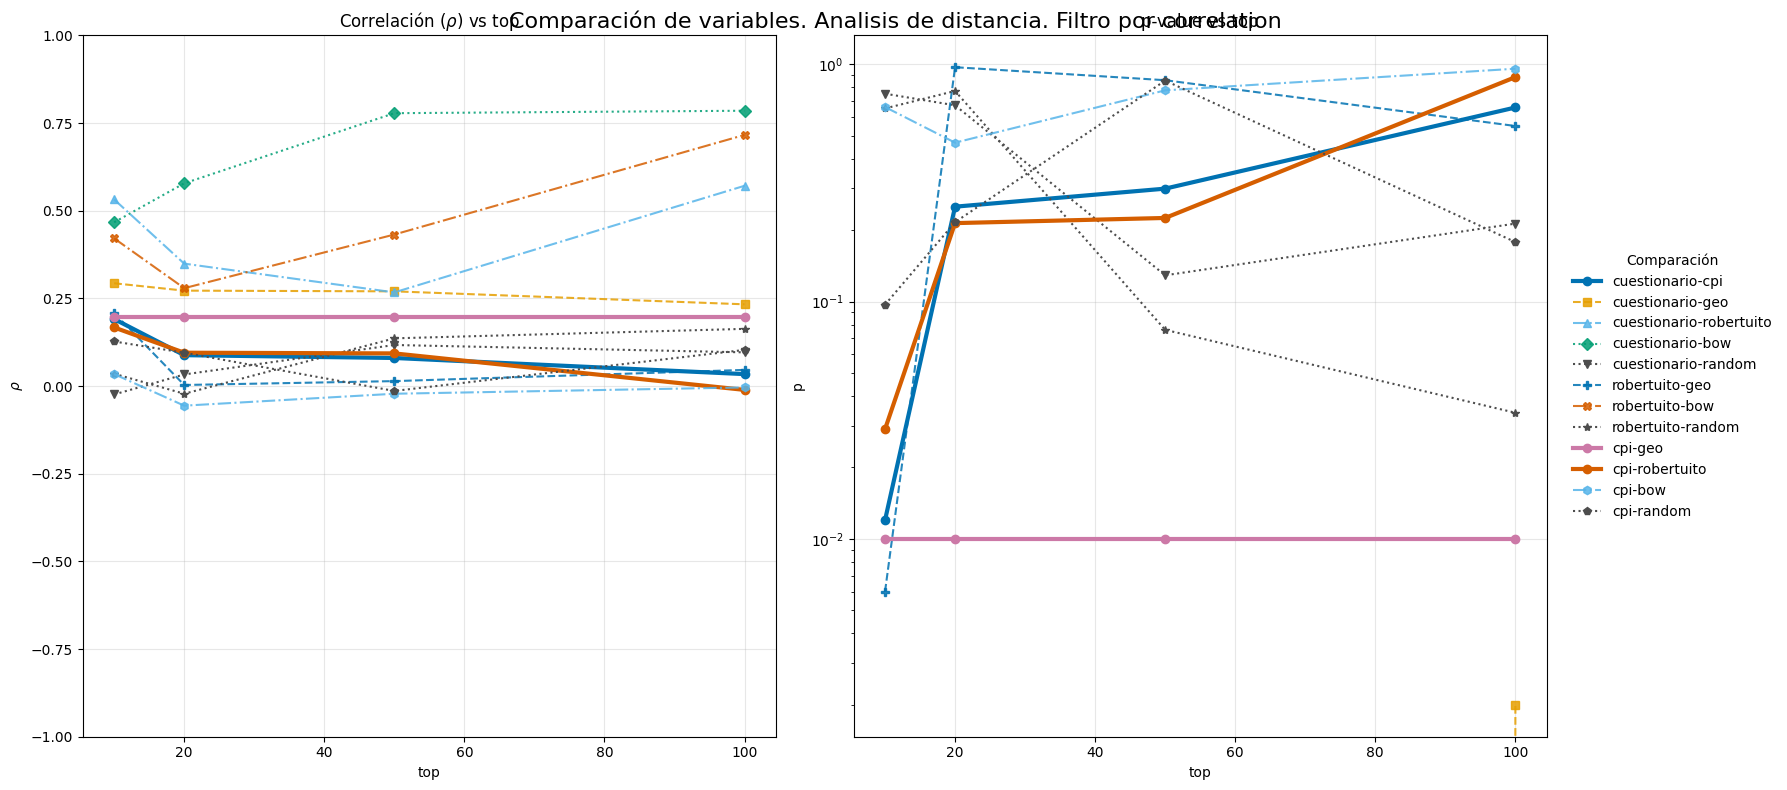

In [ ]:
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='ponderate',
    keys=thres.keys(),
    ignore=ignore, 
    segmentation=segmentation, 
    one_hot_cols=one_hot_cols, 
    expanded=True
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

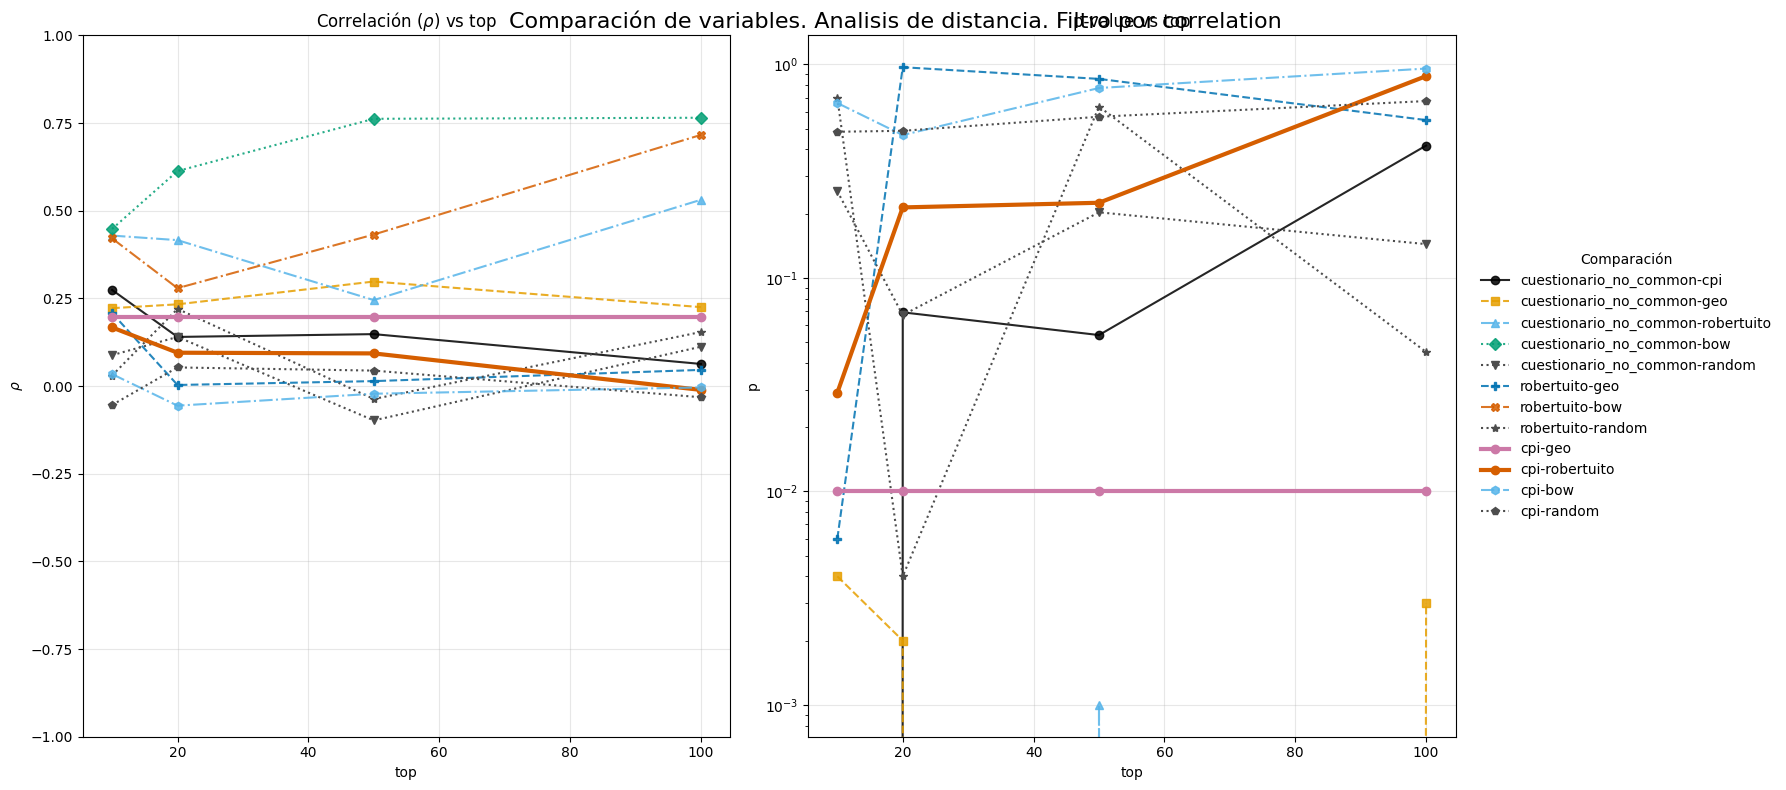

In [19]:
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='ponderate',
    keys=thres_no_common.keys(),
    ignore=ignore_no_common, 
    segmentation=segmentation, 
    one_hot_cols=one_hot_cols, 
    expanded=True,
    suffix='_no_common',
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

### Solo mas relevantes
#### umbral = 0.6

##### Filtrado por tasa de seleccion de caracteristicas
###### Relacion por correlacion

Procesando top 10...
  Calculando matrices de características...
		Calculando distancia para cuestionario...
Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.4487 para mantener 6 características.
		Calculando distancia para robertuito...
		Calculando distancia para bow...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.4089 para mantener 6 características.
  Preparando matrices de correlación...
  Vectorizando matrices de correlación...
  Calculando correlaciones...
  Preparando resultados...
Top 10 resultados:
--------------------------------------------------
        comparacion      r      p  top
0           cpi-geo  0.125  0.125   10
1  cpi-cuestionario  0.403  0.000   10
2    cpi-robertuito  0.051  0.528   10
3           cpi-bow  0.409  0.000   10
4        cpi-random  0.083  0.305   10

Procesando top 20...
  Calculando matrices de características...
		Calculando distancia para cuestionario...
Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.3973 para mantener 12 características.
		Calculando distancia para robertuito...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


		Calculando distancia para bow...
  Preparando matrices de correlación...
  Vectorizando matrices de correlación...
  Calculando correlaciones...
  Preparando resultados...
Top 20 resultados:
--------------------------------------------------
        comparacion      r      p  top
0           cpi-geo  0.125  0.125   20
1  cpi-cuestionario  0.217  0.007   20
2    cpi-robertuito  0.066  0.417   20
3           cpi-bow  0.316  0.000   20
4        cpi-random  0.067  0.413   20

Procesando top 50...
  Calculando matrices de características...
		Calculando distancia para cuestionario...


...

Advertencia: El threshold 0.6 seleccionó solo 21 características (mínimo deseado: 60). Ajustando a 0.4551.
		Calculando distancia para robertuito...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


		Calculando distancia para bow...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 seleccionó solo 45 características (mínimo deseado: 60). Ajustando a 0.5639.
  Preparando matrices de correlación...
  Vectorizando matrices de correlación...
  Calculando correlaciones...
  Preparando resultados...
Top 100 resultados:
--------------------------------------------------
        comparacion      r      p  top
0           cpi-geo  0.125  0.125  100
1  cpi-cuestionario  0.605  0.000  100
2    cpi-robertuito  0.016  0.846  100
3           cpi-bow  0.629  0.000  100
4        cpi-random -0.045  0.582  100

Combinando resultados de todos los tops...


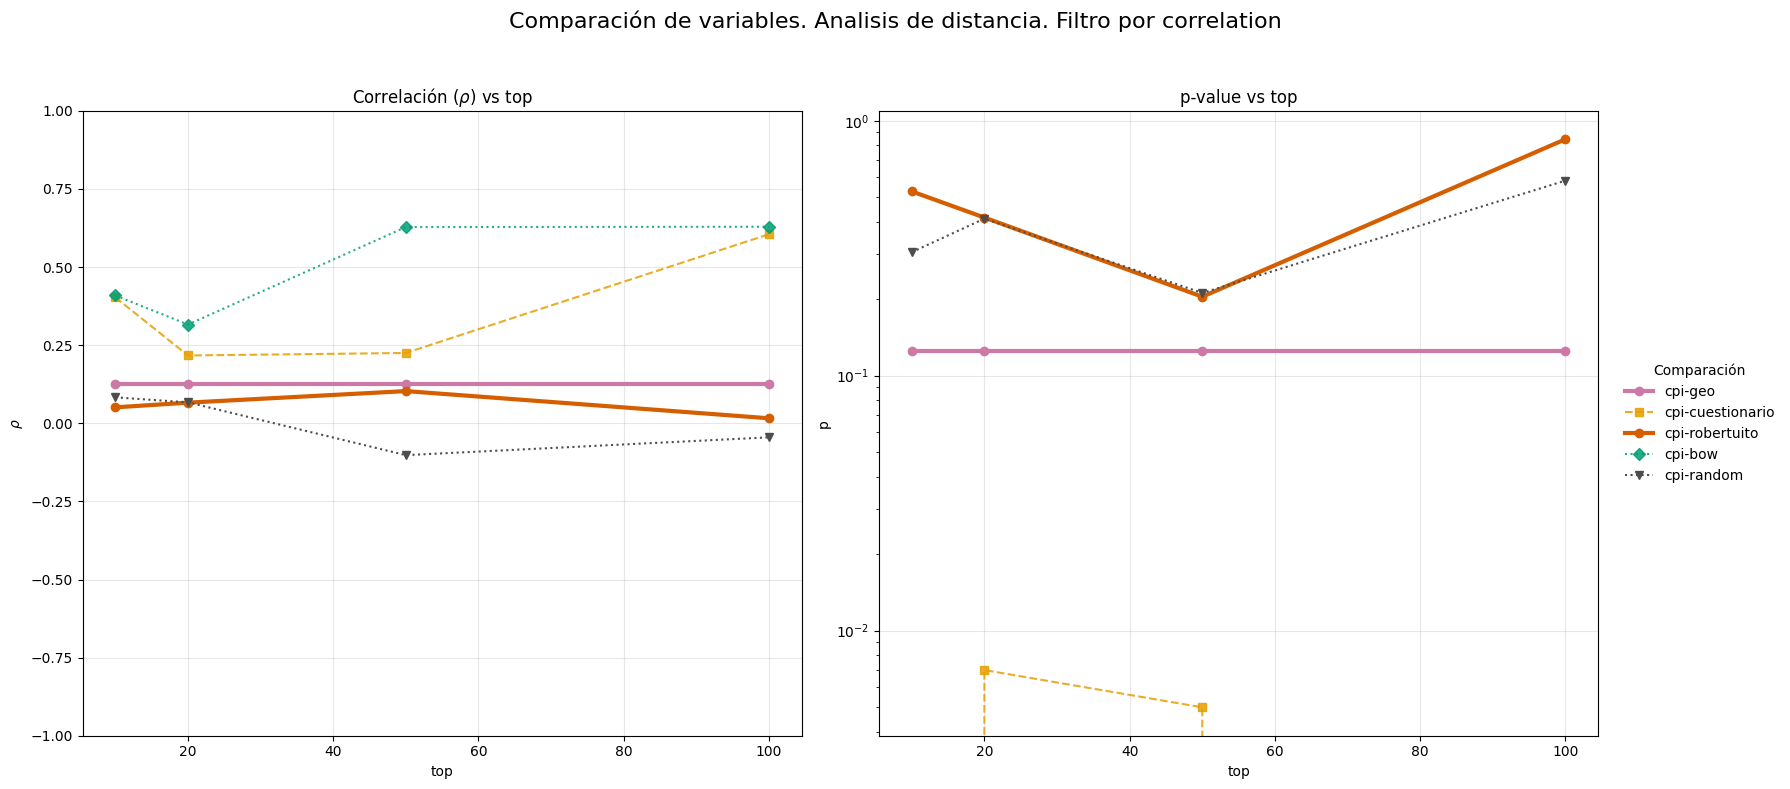

In [15]:
t = 0.6
thres = {
    'cuestionario': t,
    'robertuito': 0,
    'bow': t
}
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='distance',
    keys=thres.keys(),
    thres_dict=thres,
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True, 
    filter_by='correlation',
    #seg_feat_dict=
    #measure_relation_by='correlation',
    compare_to=df_dict["cpi"][['cpi']],
    print_progress=True,
    min_features_ratio=0.1
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

##### MI sobre dataset completo

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.4487 para mantener 6 características.
ASSYMMETRIC:  False
ASSYMMETRIC:  False
Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.3974 para mantener 9 características.
ASSYMMETRIC:  False


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.4035 para mantener 13 características.
ASSYMMETRIC:  False
ASSYMMETRIC:  False
Advertencia: El threshold 0.6 seleccionó solo 3 características (mínimo deseado: 19). Ajustando a 0.4854.
ASSYMMETRIC:  False


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


...

Advertencia: El threshold 0.6 seleccionó solo 21 características (mínimo deseado: 65). Ajustando a 0.4592.
ASSYMMETRIC:  False


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


ASSYMMETRIC:  False


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 seleccionó solo 37 características (mínimo deseado: 95). Ajustando a 0.5176.
ASSYMMETRIC:  False


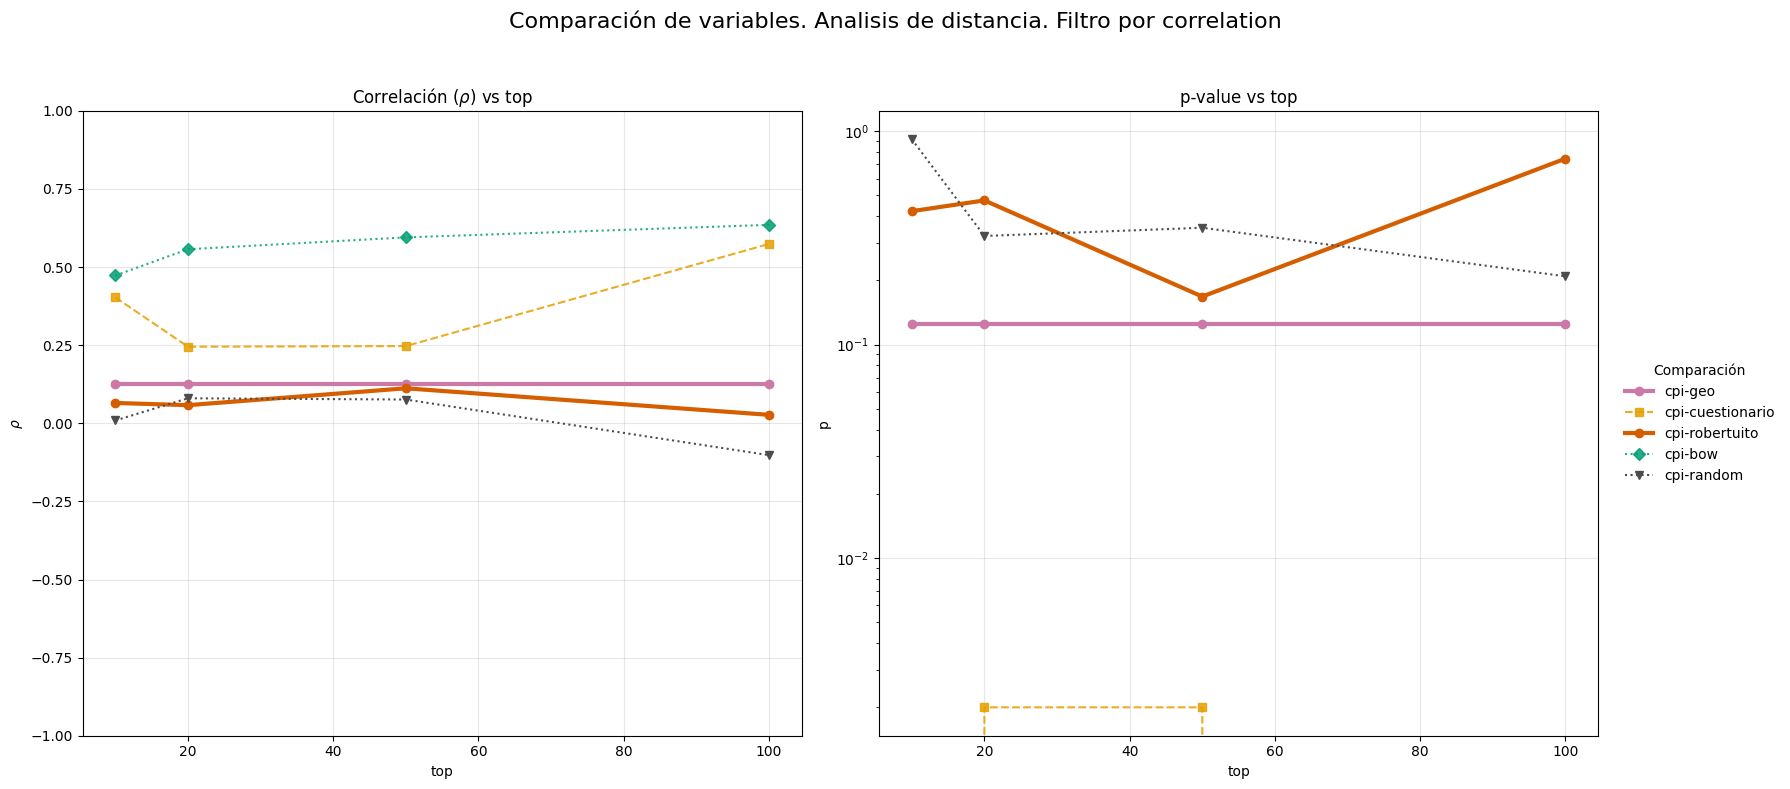

In [59]:
t = 0.6
thres = {
    'cuestionario': t,
    'robertuito': 0,
    'bow': t
}
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='distance',
    keys=thres.keys(),
    thres_dict=thres,
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True, 
    filter_by='correlation',
    #seg_feat_dict=
    #measure_relation_by='correlation',
    compare_to=df_dict["cpi"][['cpi']],
    #print_progress=True,
    min_features_ratio=0.1
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

## Solo con buena informacion mutua

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlati

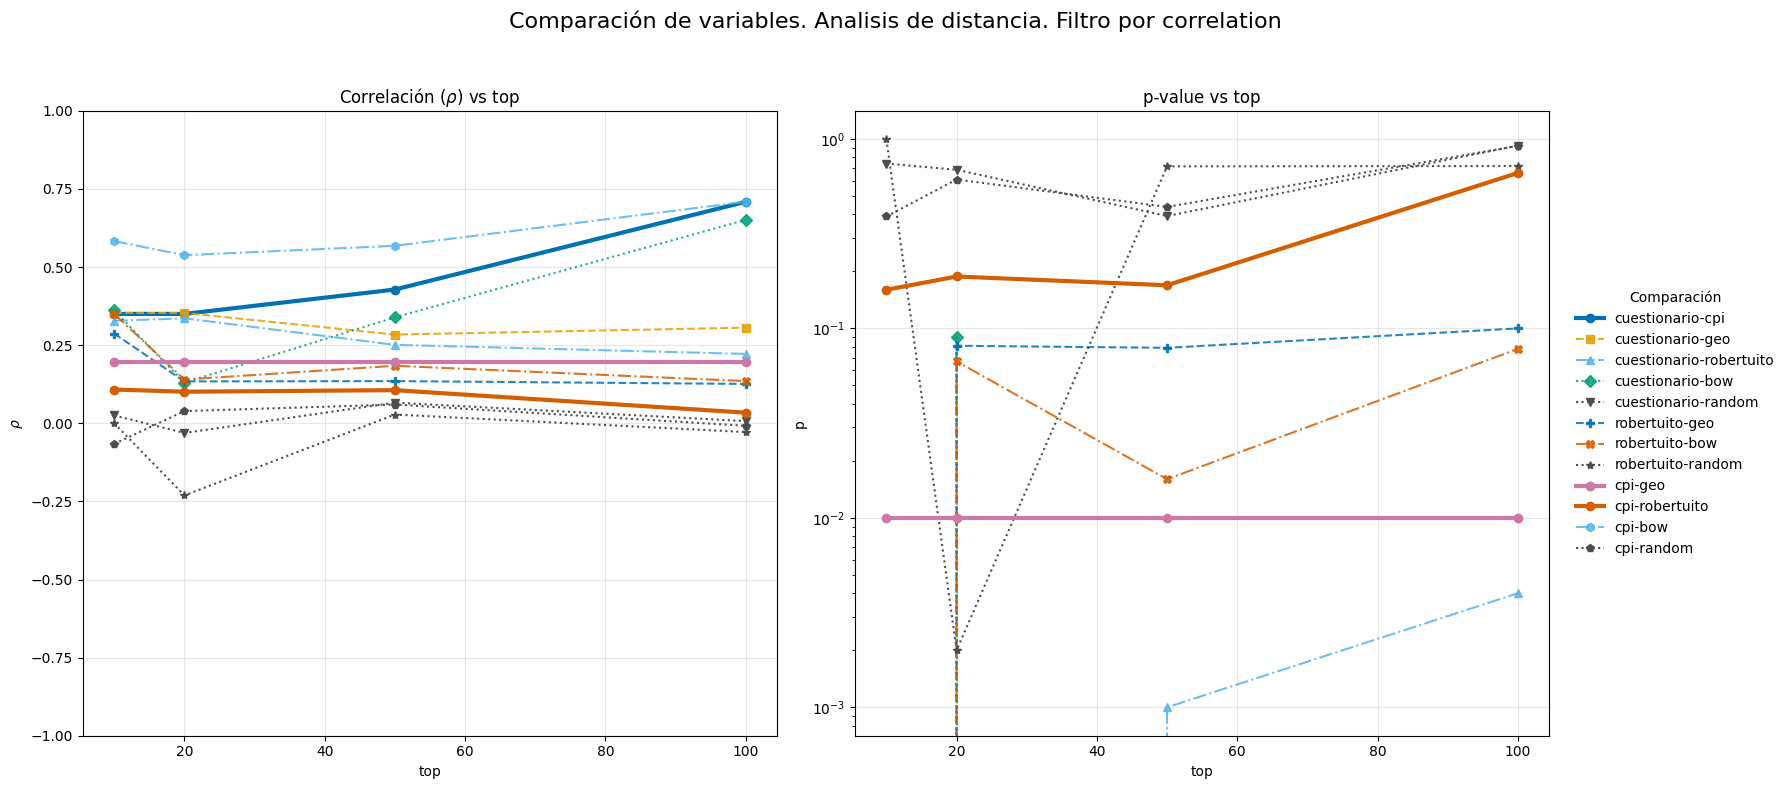

In [48]:
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='distance',
    keys=thres.keys(),
    thres_dict=thres,
    ignore=ignore, 
    segmentation=segmentation, 
    one_hot_cols=one_hot_cols, 
    expanded=True, 
    filter_by='correlation', 
    compare_to=df_dict["cpi"][['cpi']]
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlati

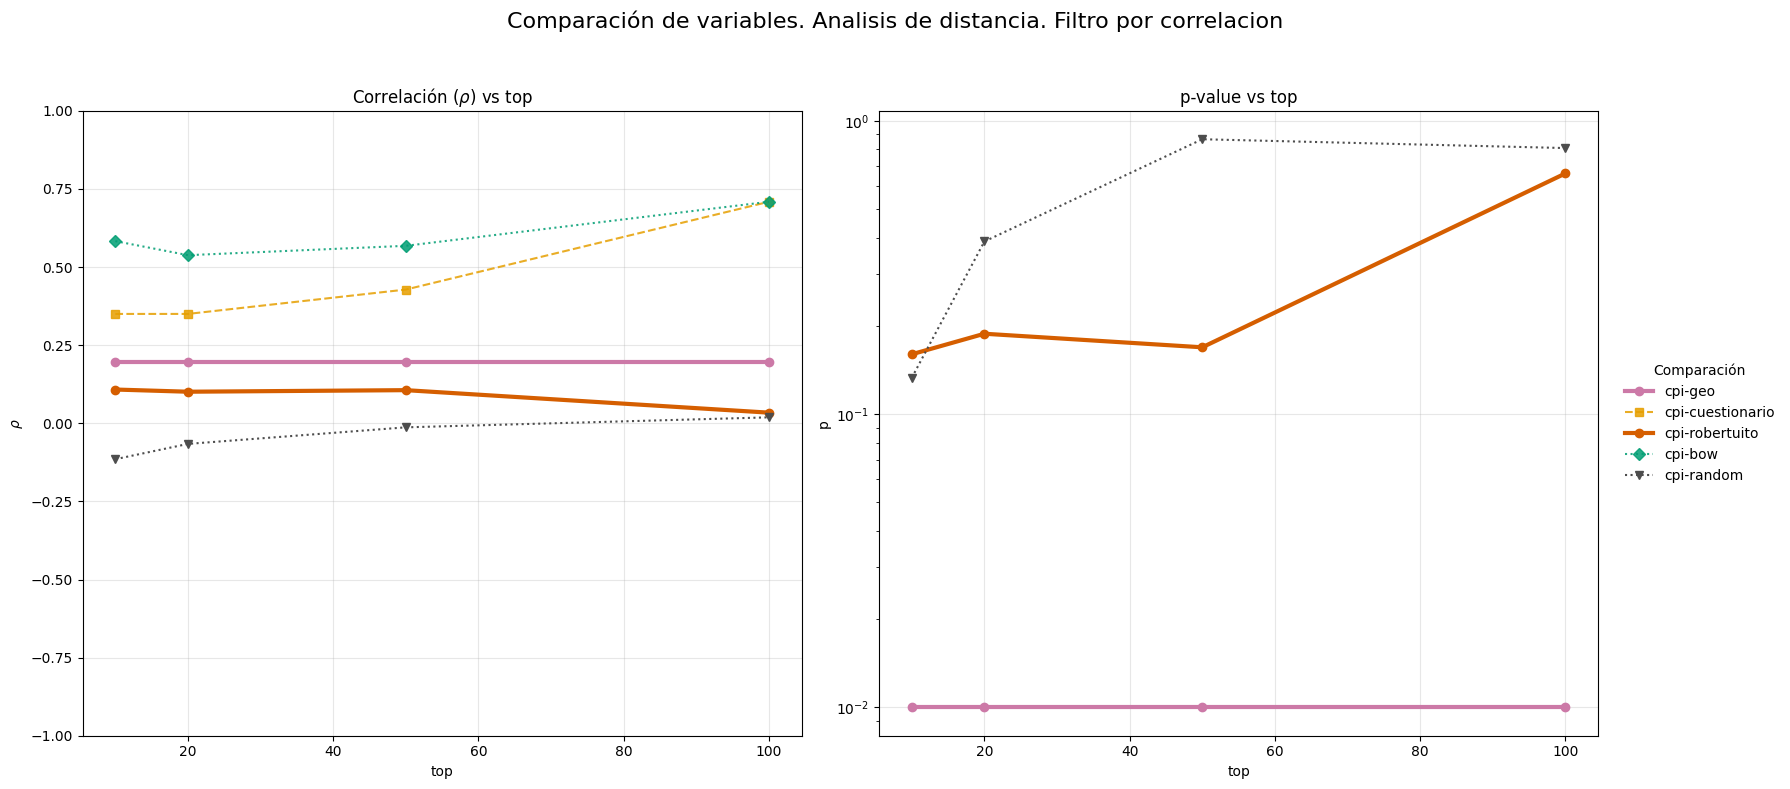

In [ ]:
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='distance',
    keys=thres.keys(),
    thres_dict=thres,
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True, 
    filter_by='correlation', 
    compare_to=df_dict["cpi"][['cpi']]
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlacion", 
    highlight_palette=HIGHLIGHT_COLORS
)

#### Sin resultados comunes

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlati

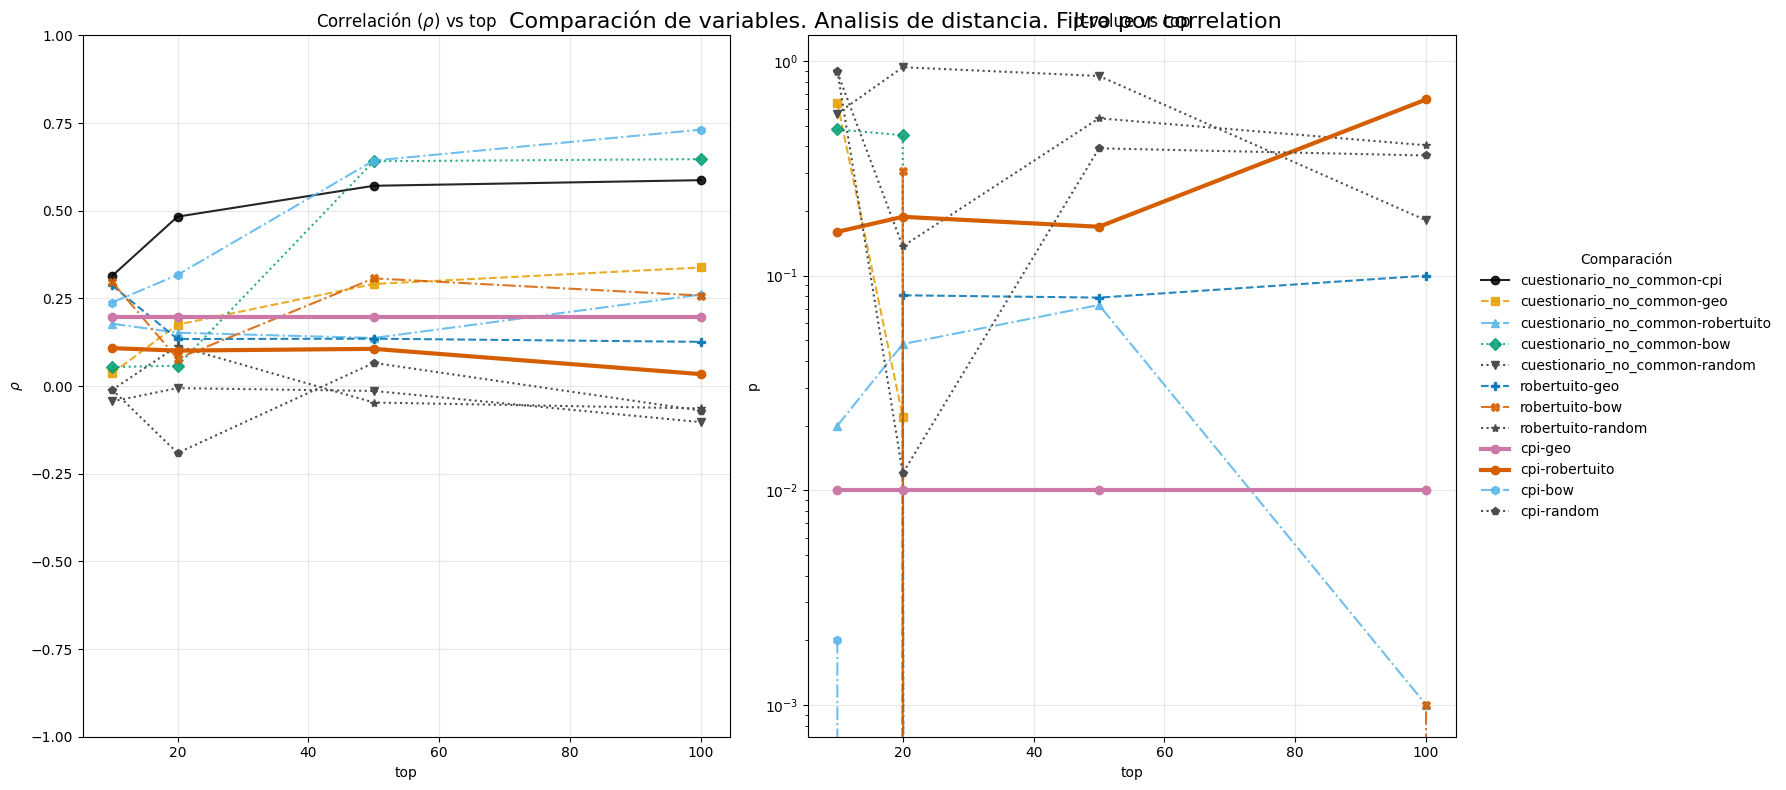

In [24]:
thres_no_common = {
    'cuestionario_no_common': 0.5,
    'robertuito': 0,
    'bow': 0.6
}

wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops, 
    corr_dict, 
    analysis_func='distance',
    keys=thres_no_common.keys(),
    thres_dict=thres_no_common,
    ignore=ignore_no_common, 
    segmentation=segmentation, 
    one_hot_cols=one_hot_cols, 
    expanded=True, 
    filter_by='correlation', 
    compare_to=df_dict["cpi"][['cpi']],
    suffix='_no_common'
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

#### Ponderado
##### Inversa de log de rango

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlati

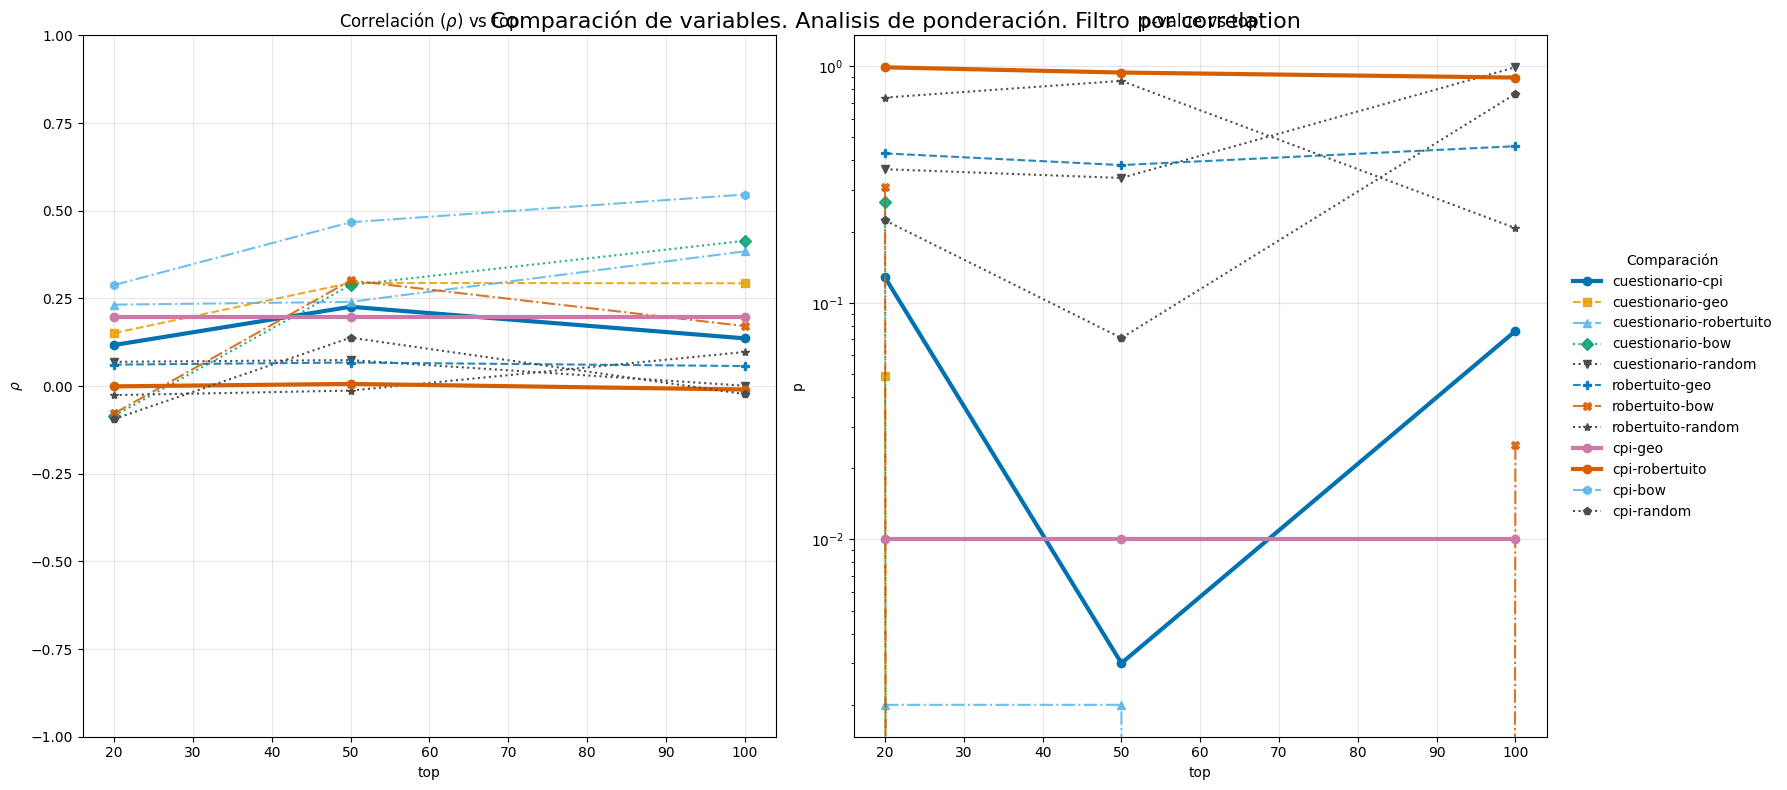

In [ ]:
thres = {
    'cuestionario': 0.3,
    'robertuito': 0,
    'bow': 0.6
}
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops[1:], 
    corr_dict, 
    analysis_func='ponderate',
    keys=thres.keys(),
    thres_dict=thres,
    start=11,
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True, 
    filter_by='correlation', 
    compare_to=df_dict["cpi"][['cpi']]
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "ponderación", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

##### Mismo peso

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib_backup.py:769: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib_backup.py:769: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib_backup.py:769: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib_backup.py:769: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib_bac

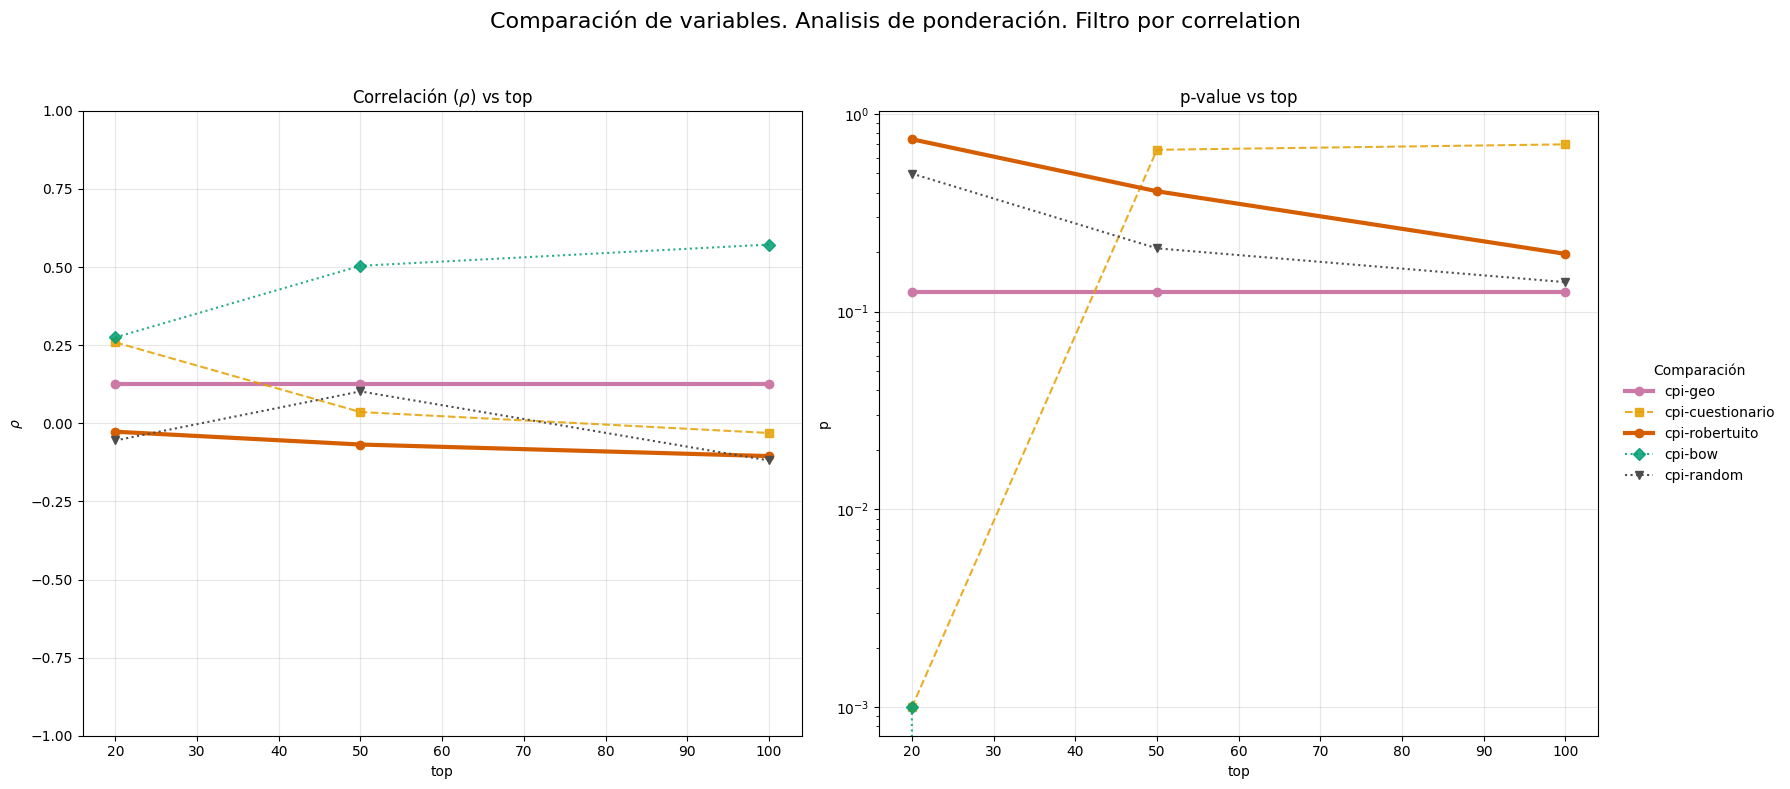

In [131]:
segmentation = 10

thres = {
    'cuestionario': 0.3,
    'robertuito': 0,
    'bow': 0.6
}

def uniform(x):
    return 1.0

wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops[1:], 
    corr_dict, 
    analysis_func='ponderate',
    weight_func=uniform,
    keys=thres.keys(),
    thres_dict=thres,
    start=11,
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True, 
    filter_by='correlation', 
    compare_to=df_dict["cpi"][['cpi']]
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "ponderación", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

### Top caracteristicas por segmento

#### Top 10

In [19]:
_, wide = srl.compute_rank_feature_distance(df_dict['rankings'][list(range(20))], df_dict['bow'], expanded=True, seg_feat_dict=seg_feat_dict['bow'])
relevance = srl.feature_relevance_multitarget(wide, df_dict["cpi"][['cpi']])
#relevant_feats = srl.get_most_relevant(relevance, threshold=0.6, by='correlation')
#relevant_feats
relevance
#srl.compute_feature_distance(wide[relevant_feats], metric="euclidean")

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:777: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


,feature,rh,p,n,target
0,romero_cum_s2,0.531563,0.023189,18,cpi
1,ro_std_s1,-0.350612,0.153729,18,cpi
2,llegado_std_s1,-0.350612,0.153729,18,cpi
3,romero_mean_s2,0.309084,0.212021,18,cpi
4,romero_std_s2,0.309084,0.212021,18,cpi
...,...,...,...,...,...
95,columnistas_mean_s2,NaN,NaN,18,cpi
96,columnistas_std_s2,NaN,NaN,18,cpi
97,columnistas_cum_s2,NaN,NaN,18,cpi
98,columnistas_diff_s2,NaN,NaN,18,cpi


Procesando top 20...
  Calculando matrices de características...
		Calculando distancia para cuestionario...
Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.3817 para mantener 10 características.
ASSYMMETRIC:  False
		Calculando distancia para robertuito...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


ASSYMMETRIC:  False
		Calculando distancia para bow...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.2385 para mantener 10 características.
ASSYMMETRIC:  False
  Preparando matrices de correlación...
  Vectorizando matrices de correlación...
  Calculando correlaciones...
  Preparando resultados...
Top 20 resultados:
--------------------------------------------------
        comparacion      r      p  top
0           cpi-geo  0.125  0.125   20
1  cpi-cuestionario  0.277  0.001   20
2    cpi-robertuito  0.103  0.205   20
3           cpi-bow  0.067  0.409   20
4        cpi-random -0.056  0.494   20

Procesando top 50...
  Calculando matrices de características...
		Calculando distancia para cuestionario...
Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.4041 para mantener 25 características.
ASSYMMETRIC:  False
		Calculando distancia para robertuito...


...

Advertencia: El threshold 0.6 seleccionó solo 16 características (mínimo deseado: 50). Ajustando a 0.4841.
ASSYMMETRIC:  False
		Calculando distancia para robertuito...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


ASSYMMETRIC:  False
		Calculando distancia para bow...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 seleccionó solo 31 características (mínimo deseado: 50). Ajustando a 0.5263.
ASSYMMETRIC:  False
  Preparando matrices de correlación...
  Vectorizando matrices de correlación...
  Calculando correlaciones...
  Preparando resultados...
Top 100 resultados:
--------------------------------------------------
        comparacion      r      p  top
0           cpi-geo  0.125  0.125  100
1  cpi-cuestionario  0.571  0.000  100
2    cpi-robertuito  0.078  0.340  100
3           cpi-bow  0.452  0.000  100
4        cpi-random -0.038  0.640  100

Combinando resultados de todos los tops...


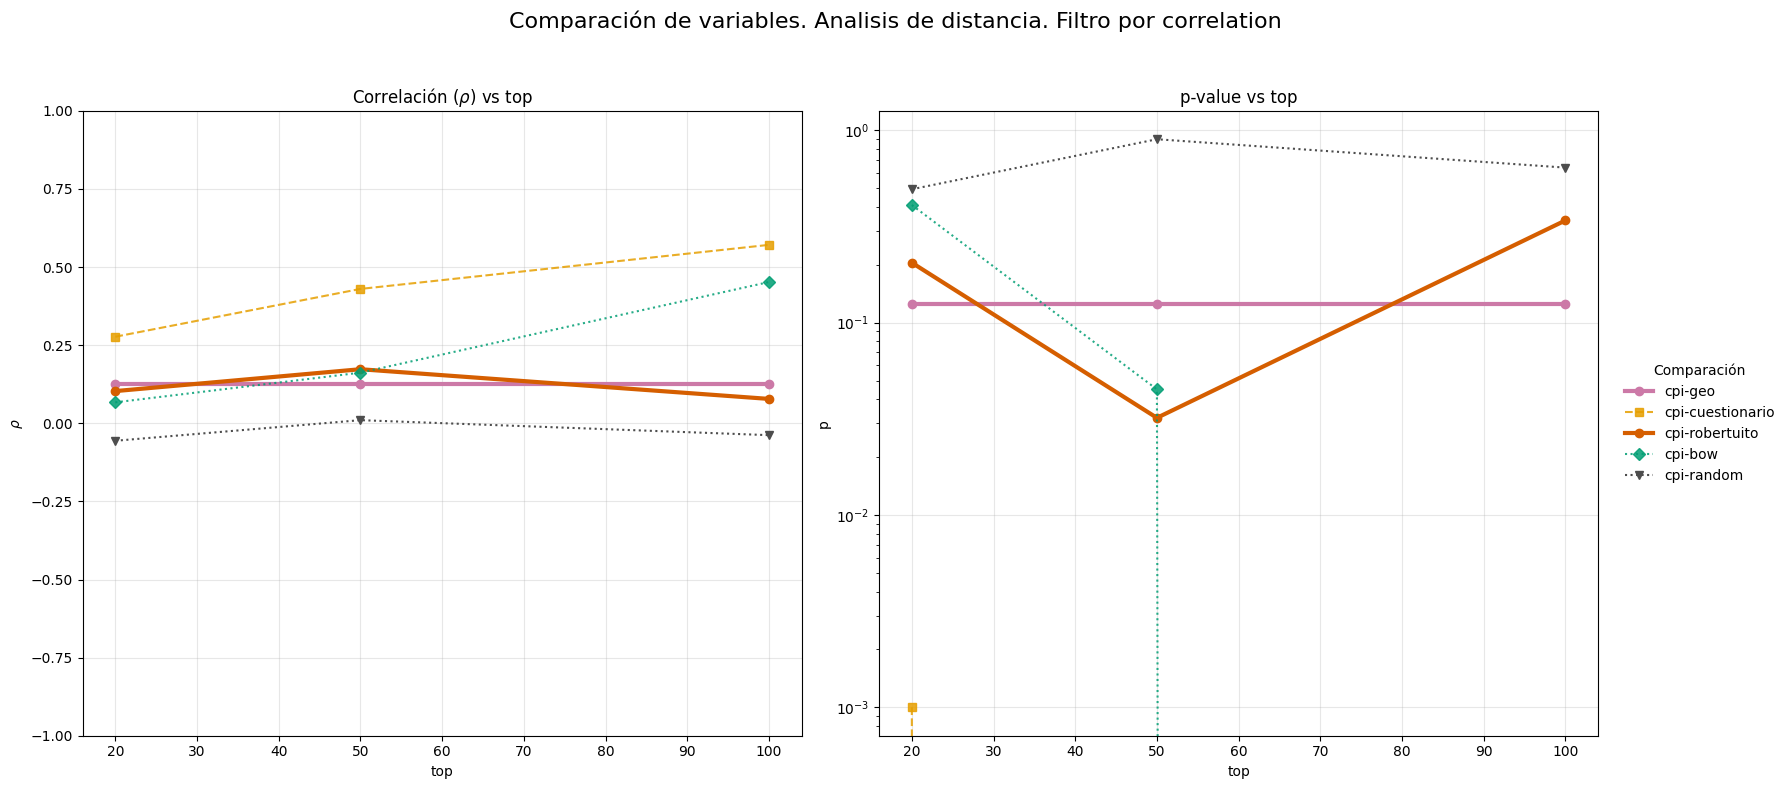

In [32]:
t = 0.6
thres = {
    'cuestionario': t,
    'robertuito': 0,
    'bow': t
}
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops[1:], 
    corr_dict, 
    analysis_func='distance',
    keys=thres.keys(),
    thres_dict=thres,
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True,
    filter_by='correlation',
    seg_feat_dicts=seg_feat_dict,
    #measure_relation_by='correlation',
    compare_to=df_dict["cpi"][['cpi']],
    print_progress=True
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

#### Top 20

Procesando top 20...
  Calculando matrices de características...
		Calculando distancia para cuestionario...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.3506 para mantener 20 características.
ASSYMMETRIC:  False
		Calculando distancia para robertuito...
ASSYMMETRIC:  False
		Calculando distancia para bow...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 seleccionó solo 4 características (mínimo deseado: 20). Ajustando a 0.2571.
ASSYMMETRIC:  False
  Preparando matrices de correlación...
  Vectorizando matrices de correlación...
  Calculando correlaciones...
  Preparando resultados...
Top 20 resultados:
--------------------------------------------------
        comparacion      r      p  top
0           cpi-geo  0.125  0.125   20
1  cpi-cuestionario  0.320  0.000   20
2    cpi-robertuito  0.066  0.417   20
3           cpi-bow  0.064  0.433   20
4        cpi-random -0.030  0.708   20

Procesando top 50...
  Calculando matrices de características...
		Calculando distancia para cuestionario...
Advertencia: El threshold 0.6 seleccionó solo 2 características (mínimo deseado: 50). Ajustando a 0.4035.
ASSYMMETRIC:  False
		Calculando distancia para robertuito...


...

Advertencia: El threshold 0.6 seleccionó solo 20 características (mínimo deseado: 100). Ajustando a 0.4487.
ASSYMMETRIC:  False
		Calculando distancia para robertuito...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


ASSYMMETRIC:  False
		Calculando distancia para bow...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/codigos/search_results_lib.py:790: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


Advertencia: El threshold 0.6 seleccionó solo 97 características (mínimo deseado: 100). Ajustando a 0.5899.
ASSYMMETRIC:  False
  Preparando matrices de correlación...
  Vectorizando matrices de correlación...
  Calculando correlaciones...
  Preparando resultados...
Top 100 resultados:
--------------------------------------------------
        comparacion      r      p  top
0           cpi-geo  0.125  0.125  100
1  cpi-cuestionario  0.512  0.000  100
2    cpi-robertuito  0.016  0.846  100
3           cpi-bow  0.558  0.000  100
4        cpi-random -0.095  0.244  100

Combinando resultados de todos los tops...


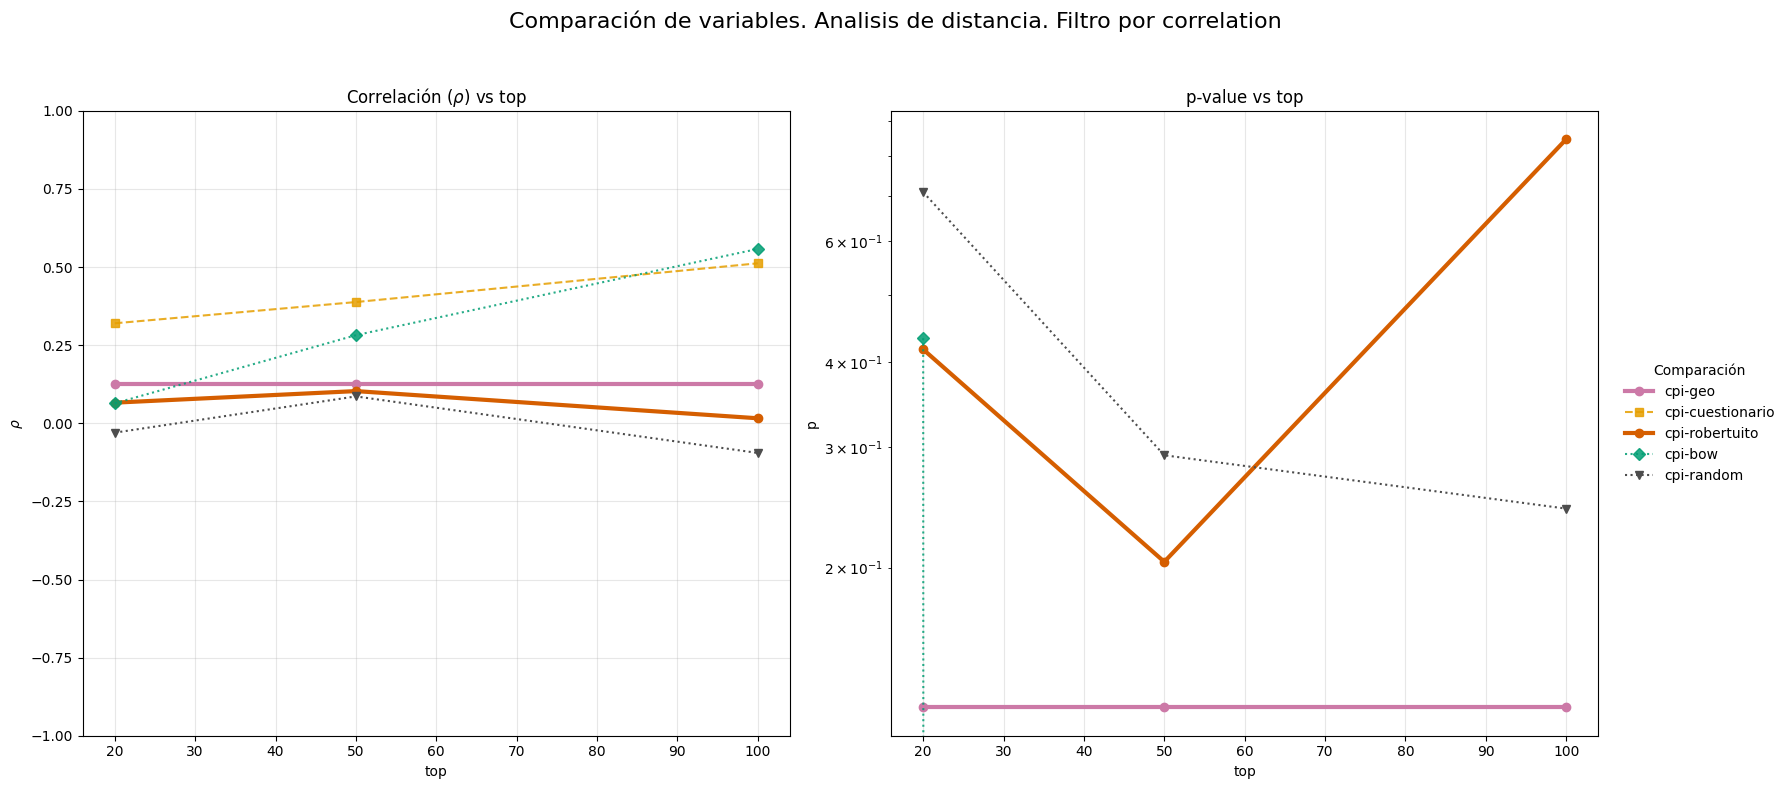

In [42]:
t = 0.6
thres = {
    'cuestionario': t,
    'robertuito': 0,
    'bow': t
}
wide_r, wide_p = srl.compare_research_variables(
    df_dict, 
    tops[1:], 
    corr_dict, 
    analysis_func='distance',
    keys=thres.keys(),
    thres_dict=thres,
    ignore=ignore, 
    segmentation=segmentation,
    expanded=True,
    filter_by='correlation',
    seg_feat_dicts=seg_feat_dict,
    #measure_relation_by='correlation',
    compare_to=df_dict["cpi"][['cpi']],
    print_progress=True
)

srl.graph_comparison(
    wide_r, 
    wide_p, 
    "distancia", 
    "correlation", 
    highlight_palette=HIGHLIGHT_COLORS
)

### Estadisticos por separado

Filtrando por all...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlati

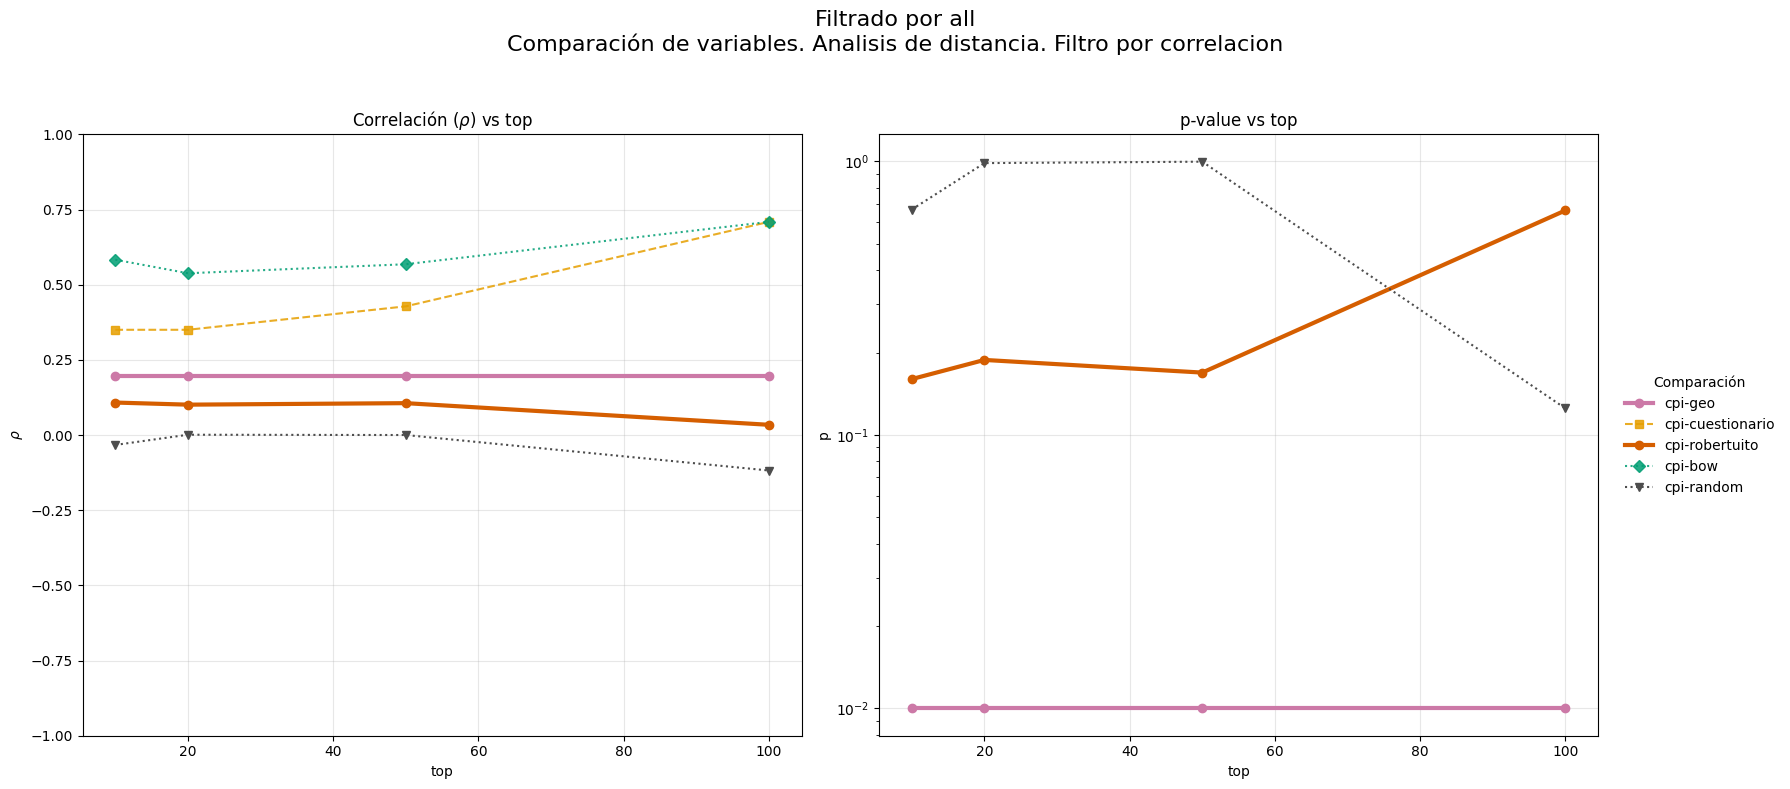

Filtrando por ['mean']...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


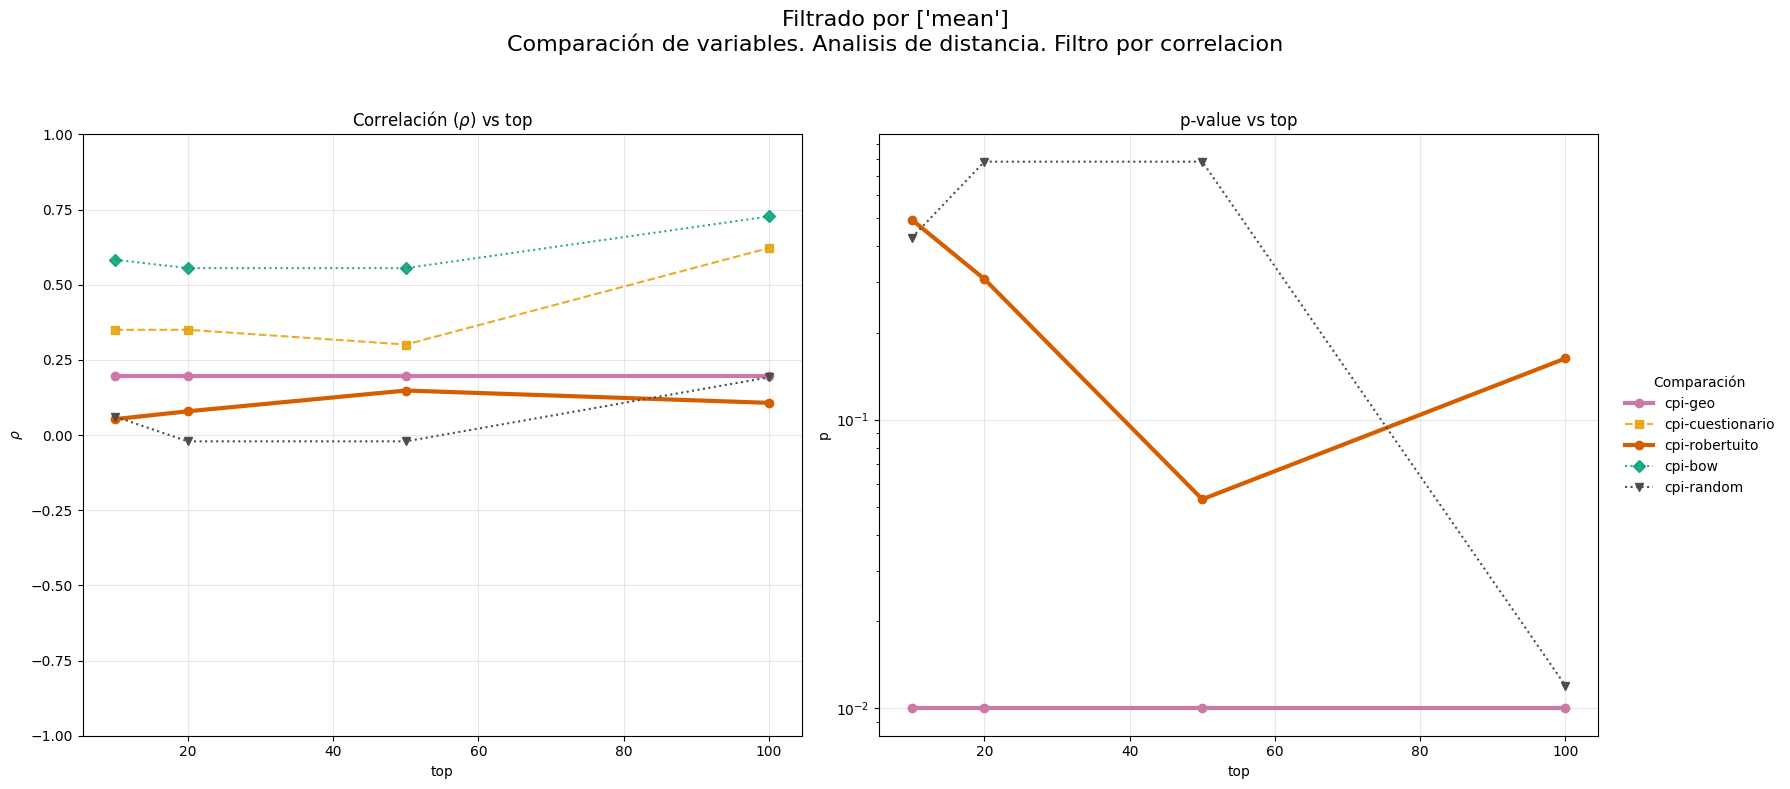

Filtrando por ['std']...
Error al filtrar por ['std']: Found array with 0 feature(s) (shape=(19, 0)) while a minimum of 1 is required by StandardScaler.
Filtrando por ['cum']...


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlati

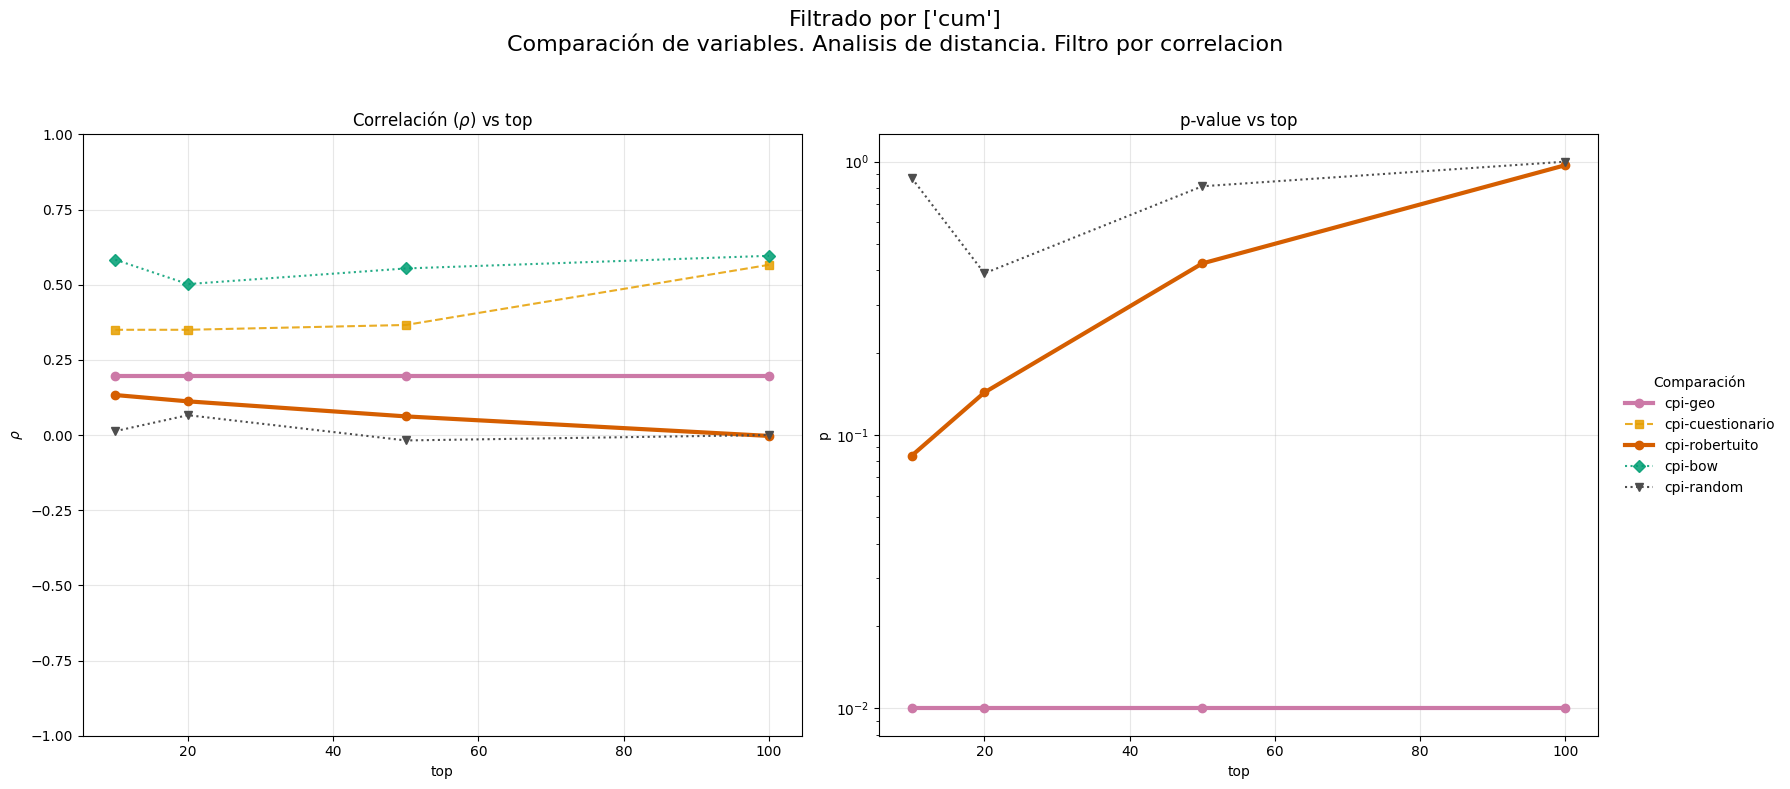

Filtrando por ['diff']...
Error al filtrar por ['diff']: Found array with 0 feature(s) (shape=(19, 0)) while a minimum of 1 is required by StandardScaler.
Filtrando por ['delta_cum']...
Error al filtrar por ['delta_cum']: Found array with 0 feature(s) (shape=(19, 0)) while a minimum of 1 is required by StandardScaler.


/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


In [26]:
for stat in ['all', ['mean'], ['std'], ['cum'], ['diff'], ['delta_cum']]:
    print(f"Filtrando por {stat}...")
    try:
        wide_r, wide_p = srl.compare_research_variables(
            df_dict, 
            tops, 
            corr_dict, 
            analysis_func='distance',
            keys=thres.keys(),
            thres_dict=thres,
            ignore=ignore, 
            segmentation=segmentation, 
            take_statistics=stat,
            expanded=True, 
            filter_by='correlation', 
            compare_to=df_dict["cpi"][['cpi']]
        )

        srl.graph_comparison(
            wide_r, 
            wide_p, 
            "distancia", 
            "correlacion", 
            extra_info=f"Filtrado por {stat}",
            highlight_palette=HIGHLIGHT_COLORS
        )
    except Exception as e:
        print(f"Error al filtrar por {stat}: {e}")

# Seleccion de features y prediccion

In [133]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, RepeatedKFold, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge, LogisticRegression
from sklearn.svm import SVR, SVC

In [134]:
def get_feature_selection_pipeline(params):
    pipe = Pipeline([
        ('select', params.get('select')),
        ('scale', params.get('scaler', StandardScaler())),
        ('clf', params.get('clf', LogisticRegression(max_iter=5000)))
    ])
    return pipe

def get_pipeline(model, scaler=None,  select=None, n_components=None, clf=None):
    steps = []
    if scaler is not None:
        steps.append(('scaler', scaler))
    if select is not None:
        if select == 'pca' and n_components is not None:
            steps.append(('select', PCA(n_components=n_components)))
        else:
            steps.append(('select', select))
    steps.append(('model', model))
    return Pipeline(steps)

def evaluate_models(X, y, models, cv, task='regression', scaler=StandardScaler(), select=None, n_components=None, dataset_name='dataset'):
    """
    Evalúa múltiples modelos con CV y devuelve un DataFrame con resultados.
    
    Parámetros
    ----------
    X : array-like o DataFrame
    y : array-like
    models : dict(nombre -> estimador sklearn)
    cv : objeto de validación cruzada
    task : {'regression', 'classification'}
    scaler : transformador o None
    select : None, 'pca' o un selector sklearn
    n_components : int o float, solo si select='pca'
    dataset_name : str, etiqueta del dataset/fuente

    Devuelve
    --------
    df_results : pd.DataFrame
    """
    rows = []

    if task == "regression":
        scoring = {
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "rmse": "neg_root_mean_squared_error",
        }
    elif task == "classification":
        scoring = {
            "accuracy": "accuracy",
            "f1_macro": "f1_macro",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
        }
    else:
        raise ValueError("task debe ser 'regression' o 'classification'.")

    CLASS_MODELS = ['LR', 'SVC_lineal', 'SVC_rbf']
    
    for name, model in models.items():
        # filtrar por tipo de tarea
        if task == "regression" and name in CLASS_MODELS:
            continue
        if task == "classification" and name not in CLASS_MODELS:
            continue

        pipe = get_pipeline(
            model=clone(model),
            scaler=scaler,
            select=select,
            n_components=n_components
        )

        cv_out = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1,
            error_score=np.nan
        )

        row = {
            "dataset": dataset_name,
            "task": task,
            "model": name,
            "selector": "none" if select is None else ("pca" if select == "pca" else type(select).__name__),
            "n_components": n_components if select == "pca" else np.nan,
            "n_samples": len(y),
            "n_features": X.shape[1],
            "n_folds": len(cv_out["fit_time"]),
        }

        for metric_name, values in cv_out.items():
            if metric_name.startswith("test_"):
                clean_name = metric_name.replace("test_", "")

                vals = np.array(values, dtype=float)

                # revertir signo de métricas "neg_*"
                if clean_name in {"mae", "mse", "rmse"}:
                    vals = -vals

                row[f"{clean_name}_mean"] = np.nanmean(vals)
                row[f"{clean_name}_std"] = np.nanstd(vals)
                row[f"{clean_name}_all"] = list(vals)

        rows.append(row)

    df_results = pd.DataFrame(rows)
    return df_results

<Axes: xlabel='cpi', ylabel='Count'>

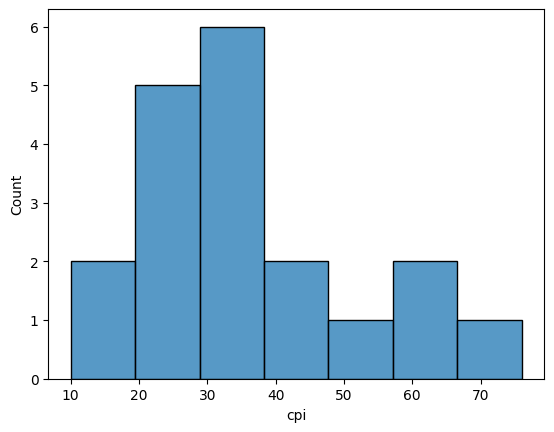

In [135]:
import seaborn as sns
sns.histplot(df_dict['cpi']['cpi'])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Venezuela'),
  Text(1, 0, 'Nicaragua'),
  Text(2, 0, 'Honduras'),
  Text(3, 0, 'Paraguay'),
  Text(4, 0, 'Guatemala'),
  Text(5, 0, 'Mexico'),
  Text(6, 0, 'Bolivia'),
  Text(7, 0, 'El Salvador'),
  Text(8, 0, 'Peru'),
  Text(9, 0, 'Ecuador'),
  Text(10, 0, 'Panama'),
  Text(11, 0, 'Dominican Republic'),
  Text(12, 0, 'Argentina'),
  Text(13, 0, 'Colombia'),
  Text(14, 0, 'Cuba'),
  Text(15, 0, 'Spain'),
  Text(16, 0, 'Costa Rica'),
  Text(17, 0, 'Chile'),
  Text(18, 0, 'Uruguay')])

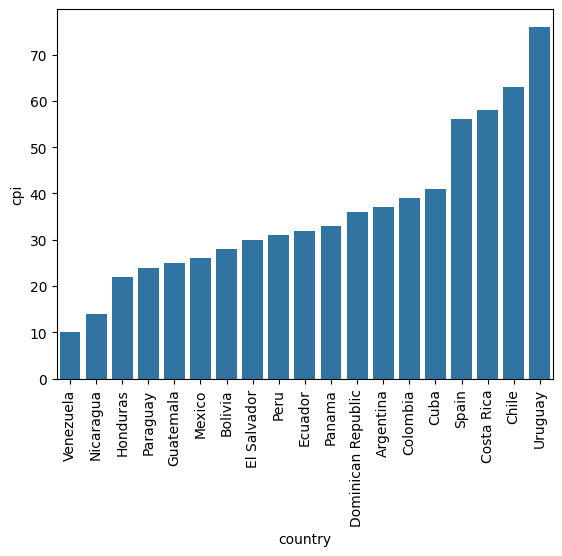

In [136]:
sns.barplot(x=df_dict['cpi'].index, y=df_dict['cpi']['cpi'], order=df_dict['cpi'].sort_values('cpi').index)
plt.xticks(rotation=90)

/tmp/ipykernel_21528/3281217937.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dict['regresion'][f'{i}-clases'] = pd.qcut(df_dict['cpi']['cpi'], q=i, labels=dict_class_names[i])
/tmp/ipykernel_21528/3281217937.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dict['regresion'][f'{i}-clases'] = pd.qcut(df_dict['cpi']['cpi'], q=i, labels=dict_class_names[i])
/tmp/ipykernel_21528/3281217937.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

<Axes: xlabel='3-clases', ylabel='cpi'>

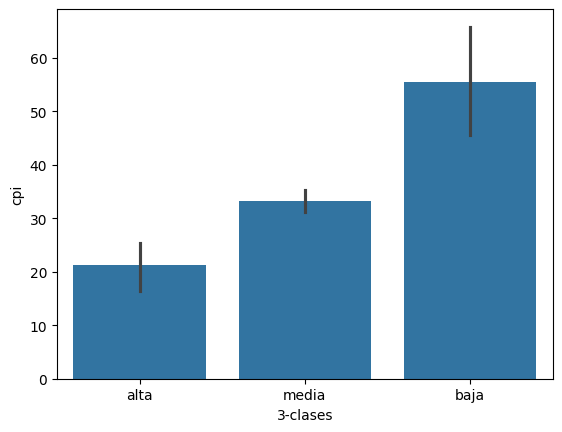

In [137]:
df_dict['regresion'] = df_dict['cpi'][['cpi']]
dict_class_names = {
    2: ['alta', 'baja'],
    3: ['alta', 'media', 'baja'],
    4: ['muy alta', 'alta', 'baja', 'muy baja']
}
for i in [2, 3, 4]:
    df_dict['regresion'][f'{i}-clases'] = pd.qcut(df_dict['cpi']['cpi'], q=i, labels=dict_class_names[i])
sns.barplot(x=df_dict['regresion']['3-clases'], y=df_dict['cpi']['cpi'], order=dict_class_names[3])

In [138]:
df_dict['regresion']

,cpi,2-clases,3-clases,4-clases
country,,,,
Argentina,37,baja,media,baja
Bolivia,28,alta,alta,alta
Chile,63,baja,baja,muy baja
Colombia,39,baja,baja,baja
Costa Rica,58,baja,baja,muy baja
Cuba,41,baja,baja,muy baja
Dominican Republic,36,baja,media,baja
Ecuador,32,alta,media,alta
El Salvador,30,alta,media,alta


## Ganancia de informacion sobre dataset completo

In [61]:
segmentation = 10

# FEATURES forms
_, paises_forms = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["cuestionario"],
    segment_size=segmentation,
    expanded=True,
    by="correlation",
    threshold=0.6,
    compare_to=df_dict["regresion"][["cpi"]]
)

#X_forms = paises_forms.values

# FEATURES robertuito
_, paises_robertuito = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["robertuito"],
    segment_size=segmentation,
    expanded=True
)

#X_robertuito = paises_robertuito.values

# FEATURES bow
_, paises_bow = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["bow"],
    segment_size=segmentation,
    expanded=True,
    by="correlation",
    threshold=0.6,
    compare_to=df_dict["regresion"][["cpi"]]
)

#X_bow = paises_bow.values

feature_sets = {
    "forms": paises_forms,
    "robertuito": paises_robertuito,
    "bow": paises_bow,
}

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])
/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


In [62]:
# Diccionario para almacenar resultados de ganancia de información
mi_results = []

for target_name in df_dict['regresion'].columns[1:]:
    print(f"\n===== Target: {target_name} =====")
    
    y_series = df_dict['regresion'][target_name]

    for dataset_name, X_df in feature_sets.items():
        print(f"\n--- Dataset: {dataset_name} ---")

        # Alinear índices y quitar NaN en y
        common_idx = X_df.index.intersection(y_series.dropna().index)
        X_df_aligned = X_df.loc[common_idx]
        y_aligned = y_series.loc[common_idx]

        X = X_df_aligned.values
        y = y_aligned.values
        feature_names = X_df_aligned.columns.to_numpy()

        # Calcular ganancia de información para cada feature
        mi_scores = mutual_info_classif(
            X, y,
            random_state=42,  # Para reproducibilidad
            n_neighbors=3,    # Número de vecinos (default es 3)
            discrete_features='auto'  # Detecta automáticamente features discretas
        )

        # Guardar resultados
        for feature, mi_score in zip(feature_names, mi_scores):
            mi_results.append({
                "target": target_name,
                "dataset": dataset_name,
                "feature": feature,
                "mutual_information": mi_score,
                "mutual_information_normalized": mi_score / np.log2(len(np.unique(y))) if len(np.unique(y)) > 1 else mi_score
            })

# Crear DataFrame con resultados
mi_df = pd.DataFrame(mi_results)

# Ordenar por ganancia de información (mayor a menor)
mi_df = mi_df.sort_values(['target', 'dataset', 'mutual_information'], 
                          ascending=[True, True, False])

# Guardar a CSV
mi_df.to_csv("mutual_information_all_features.csv", index=False)

# Mostrar top features por target/dataset
print("\n=== Top 5 features por ganancia de información ===")
print(mi_df.groupby(['target', 'dataset']).head(5))


===== Target: 2-clases =====

--- Dataset: forms ---

--- Dataset: robertuito ---

--- Dataset: bow ---

===== Target: 3-clases =====

--- Dataset: forms ---

--- Dataset: robertuito ---

--- Dataset: bow ---

===== Target: 4-clases =====

--- Dataset: forms ---

--- Dataset: robertuito ---

--- Dataset: bow ---

=== Top 5 features por ganancia de información ===
         target     dataset                                feature  \
652    2-clases         bow                   environmental_cum_s6   
889    2-clases         bow               presentarse_delta_cum_s8   
7461   2-clases         bow                       oficiales_std_s6   
7583   2-clases         bow                 oficiales_delta_cum_s6   
7595   2-clases         bow                              32_std_s6   
19     2-clases       forms                   emociones__e_mean_s6   
6      2-clases       forms         consecuencias__b_delta_cum_s10   
25     2-clases       forms              emociones__e_delta_cum_s6   
9  

In [37]:
mi_df = pd.read_csv("mutual_information_all_features.csv")
mi_df['clean_feature'] = mi_df['feature'].str.replace(
    r'_(?:cum|diff|std|mean|max|min|sum|delta|delta_cum)_s\d+$', 
    '', 
    regex=True
)
mi_df['segment'] = mi_df['feature'].str.extract(r'_(cum|diff|std|mean|max|min|sum|delta|delta_cum)_s(\d+)$', expand=True)[1].astype(int)
mi = mi_df[['dataset', 'clean_feature', 'mutual_information']].groupby(['dataset', 'clean_feature']).mean().reset_index()
#mi.sort_values(['target', 'dataset', 'mutual_information'], ascending=[True, True, False], inplace=True)
#mi[mi['mutual_information']>0.2]
mi

,dataset,clean_feature,mutual_information
0,bow,00,0.182452
1,bow,000 00,0.331667
2,bow,000 millones,0.281910
3,bow,04,0.204811
4,bow,05,0.123716
...,...,...,...
2641,robertuito,hate__speech__hateful,0.022579
2642,robertuito,hate__speech__targeted,0.025860
2643,robertuito,irony__ironic,0.023272
2644,robertuito,sentiment__NEG,0.046305


In [64]:
top_n_per_dataset = mi.groupby('dataset').apply(
    lambda x: x.nlargest(20, 'mutual_information')
).reset_index(drop=True)
top_n_per_dataset.sort_values(['dataset', 'mutual_information'], ascending=[True, False], inplace=True)
top_n_per_dataset.to_csv("mutual_information_top_per_dataset.csv", index=False)
top_n_per_dataset

,dataset,clean_feature,segment,mutual_information
0,bow,sobresueldos,8,1.275731
1,bow,figuran,3,1.007883
2,bow,excepcional,1,0.984823
3,bow,violencia mujeres,8,0.891851
4,bow,corrupción cuales,2,0.839333
5,bow,libremente,5,0.837557
6,bow,inexistentes,3,0.817856
7,bow,convirtió,5,0.796381
8,bow,dirigido,2,0.784366
9,bow,utilizadas,8,0.770313


In [43]:
mi = mi_df[['dataset', 'clean_feature', 'segment', 'mutual_information']].groupby(['dataset', 'clean_feature', 'segment']).mean().reset_index()
top_n_per_segment = mi.groupby(['dataset', 'segment']).apply(
    lambda x: x.nlargest(20, 'mutual_information')
).reset_index(drop=True)
top_n_per_segment.sort_values(['dataset', 'segment', 'mutual_information'], ascending=[True, True, False], inplace=True)
top_n_per_segment.to_csv("mutual_information_top_per_segment.csv", index=False)
top_n_per_segment


,dataset,clean_feature,segment,mutual_information
0,bow,excepcional,1,0.984823
1,bow,sistemas,1,0.387220
2,bow,canales,1,0.221284
3,bow,práctica,1,0.180270
4,bow,impuestos,1,0.054405
...,...,...,...,...
323,robertuito,emotion__surprise,10,0.028288
324,robertuito,emotion__fear,10,0.022207
325,robertuito,emotion__sadness,10,0.014087
326,robertuito,hate__speech__targeted,10,0.012573


## Seleccion

In [22]:
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "logreg": {
        "select": SelectKBest(score_func=mutual_info_classif),
        "scaler": StandardScaler(),
        "clf": LogisticRegression(max_iter=5000)
    },
    'svc': {
        "select": SelectKBest(score_func=mutual_info_classif),
        "scaler": StandardScaler(),
        "clf": SVC()
    }
}

param_grids = {
    "logreg": {
        "select__k": [20],#[5, 10, 20, 50, "all"],
        "clf__C": [0.01, 0.1, 1, 10],
    },
    "svc": {
        "select__k": [20],#[5, 10, 20, 50, "all"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__kernel": ["linear", "rbf"],
        "clf__gamma": ["scale", "auto"],
    },
}

In [ ]:
from collections import Counter, defaultdict
from sklearn.metrics import accuracy_score, f1_score

results = []
selected_features_rows = []
selection_frequency = defaultdict(Counter)
scores_rows = []

for target_name in df_dict['regresion'].columns[1:]:
    print(f"\n===== Target: {target_name} =====")
    
    y_series = df_dict['regresion'][target_name]

    for dataset_name, X_df in feature_sets.items():
        print(f"\n--- Dataset: {dataset_name} ---")

        # Alinear índices y quitar NaN en y
        common_idx = X_df.index.intersection(y_series.dropna().index)
        X_df_aligned = X_df.loc[common_idx]
        y_aligned = y_series.loc[common_idx]

        X = X_df_aligned.values
        y = y_aligned.values
        feature_names = X_df_aligned.columns.to_numpy()

        valid_k = [k for k in [5, 10, 20, 50] if k <= X.shape[1]] + ["all"]

        for model_name in models.keys():
            print(f"Model: {model_name}")

            model_param_grid = param_grids[model_name].copy()
            model_param_grid["select__k"] = valid_k

            fold_accuracies = []
            fold_f1s = []

            for fold_id, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), start=1):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                search = GridSearchCV(
                    estimator=get_feature_selection_pipeline(models[model_name]),
                    param_grid=model_param_grid,
                    cv=cv_inner,
                    scoring="f1_macro",
                    n_jobs=-1
                )

                search.fit(X_train, y_train)

                best_pipe = search.best_estimator_
                y_pred = best_pipe.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average="macro")

                fold_accuracies.append(acc)
                fold_f1s.append(f1)

                # Features seleccionadas en este fold
                selector = best_pipe.named_steps["select"]
                mask = selector.get_support()
                selected_features = feature_names[mask]

                # Guardar lista por fold
                selected_features_rows.append({
                    "target": target_name,
                    "dataset": dataset_name,
                    "model": model_name,
                    "fold": fold_id,
                    "n_selected": len(selected_features),
                    "selected_features": list(selected_features),
                    "best_params": search.best_params_
                })

                for feat, score, is_selected in zip(feature_names, selector.scores_, selector.get_support()):
                    scores_rows.append({
                        "target": target_name,
                        "dataset": dataset_name,
                        "model": model_name,
                        "fold": fold_id,
                        "feature": feat,
                        "score": score,
                        "selected": bool(is_selected)
                    })

                # Contar frecuencia
                key = (target_name, dataset_name, model_name)
                selection_frequency[key].update(selected_features)

            # Resumen de métricas para esta combinación
            results.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                "n_samples": len(y),
                "n_features": X.shape[1],
                "accuracy_mean": np.mean(fold_accuracies),
                "accuracy_std": np.std(fold_accuracies),
                "f1_macro_mean": np.mean(fold_f1s),
                "f1_macro_std": np.std(fold_f1s),
            })

results_df = pd.DataFrame(results).sort_values(
    ['target', 'f1_macro_mean'],
    ascending=[True, False]
)

selected_features_df = pd.DataFrame(selected_features_rows)

feature_scores_df = pd.DataFrame(scores_rows)

freq_rows = []

for (target_name, dataset_name, model_name), counter in selection_frequency.items():
    total_folds = cv_outer.get_n_splits()
    for feat, count in counter.items():
        freq_rows.append({
            "target": target_name,
            "dataset": dataset_name,
            "model": model_name,
            "feature": feat,
            "times_selected": count,
            "selection_rate": count / total_folds
        })

selection_freq_df = pd.DataFrame(freq_rows).sort_values(
    ["target", "dataset", "model", "selection_rate", "times_selected"],
    ascending=[True, True, True, False, False]
)

selected_features_df_to_save = selected_features_df.copy()
selected_features_df_to_save["selected_features"] = selected_features_df_to_save["selected_features"].apply(
    lambda x: " | ".join(x)
)
selected_features_df_to_save["best_params"] = selected_features_df_to_save["best_params"].astype(str)

results_df.to_csv("clf_results_summary.csv", index=False)
selected_features_df_to_save.to_csv("clf_selected_features_by_fold.csv", index=False)
selection_freq_df.to_csv("clf_feature_selection_frequency.csv", index=False)
feature_scores_df.to_csv("clf_feature_scores_by_fold.csv", index=False)


===== Target: 2-clases =====

--- Dataset: bow ---
Model: logreg


KeyboardInterrupt: 

In [21]:
_, paises_bow = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["bow"],
    segment_size=segmentation,
    expanded=True,
    by="correlation",
    threshold=0.6,
    compare_to=df_dict["regresion"][["cpi"]],
    take_segments=[2,3,8,10],
    take_statistics=['mean', 'diff', 'cum']
)

#X_bow = paises_bow.values

feature_sets = {
    #"forms": paises_forms,
    #"robertuito": paises_robertuito,
    "bow": paises_bow,
}

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "logreg": {
        "select": SelectKBest(score_func=mutual_info_classif),
        "scaler": StandardScaler(),
        "clf": LogisticRegression(max_iter=5000)
    },
    'svc': {
        "select": SelectKBest(score_func=mutual_info_classif),
        "scaler": StandardScaler(),
        "clf": SVC()
    }
}

param_grids = {
    "logreg": {
        "select__k": [20],#[5, 10, 20, 50, "all"],
        "clf__C": [0.01, 0.1, 1, 10],
    },
    "svc": {
        "select__k": [20],#[5, 10, 20, 50, "all"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__kernel": ["linear", "rbf"],
        "clf__gamma": ["scale", "auto"],
    },
}

from collections import Counter, defaultdict
from sklearn.metrics import accuracy_score, f1_score

results = []
selected_features_rows = []
selection_frequency = defaultdict(Counter)
scores_rows = []

for target_name in df_dict['regresion'].columns[1:]:
    print(f"\n===== Target: {target_name} =====")
    
    y_series = df_dict['regresion'][target_name]

    for dataset_name, X_df in feature_sets.items():
        print(f"\n--- Dataset: {dataset_name} ---")

        # Alinear índices y quitar NaN en y
        common_idx = X_df.index.intersection(y_series.dropna().index)
        X_df_aligned = X_df.loc[common_idx]
        y_aligned = y_series.loc[common_idx]

        X = X_df_aligned.values
        y = y_aligned.values
        feature_names = X_df_aligned.columns.to_numpy()

        valid_k = [k for k in [5, 10, 20, 50] if k <= X.shape[1]] + ["all"]

        for model_name in models.keys():
            print(f"Model: {model_name}")

            model_param_grid = param_grids[model_name].copy()
            model_param_grid["select__k"] = valid_k

            fold_accuracies = []
            fold_f1s = []

            for fold_id, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), start=1):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                search = GridSearchCV(
                    estimator=get_feature_selection_pipeline(models[model_name]),
                    param_grid=model_param_grid,
                    cv=cv_inner,
                    scoring="f1_macro",
                    n_jobs=-1
                )

                search.fit(X_train, y_train)

                best_pipe = search.best_estimator_
                y_pred = best_pipe.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average="macro")

                fold_accuracies.append(acc)
                fold_f1s.append(f1)

                # Features seleccionadas en este fold
                selector = best_pipe.named_steps["select"]
                mask = selector.get_support()
                selected_features = feature_names[mask]

                # Guardar lista por fold
                selected_features_rows.append({
                    "target": target_name,
                    "dataset": dataset_name,
                    "model": model_name,
                    "fold": fold_id,
                    "n_selected": len(selected_features),
                    "selected_features": list(selected_features),
                    "best_params": search.best_params_
                })

                for feat, score, is_selected in zip(feature_names, selector.scores_, selector.get_support()):
                    scores_rows.append({
                        "target": target_name,
                        "dataset": dataset_name,
                        "model": model_name,
                        "fold": fold_id,
                        "feature": feat,
                        "score": score,
                        "selected": bool(is_selected)
                    })

                # Contar frecuencia
                key = (target_name, dataset_name, model_name)
                selection_frequency[key].update(selected_features)

            # Resumen de métricas para esta combinación
            results.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                "n_samples": len(y),
                "n_features": X.shape[1],
                "accuracy_mean": np.mean(fold_accuracies),
                "accuracy_std": np.std(fold_accuracies),
                "f1_macro_mean": np.mean(fold_f1s),
                "f1_macro_std": np.std(fold_f1s),
            })

results_df = pd.DataFrame(results).sort_values(
    ['target', 'f1_macro_mean'],
    ascending=[True, False]
)

selected_features_df = pd.DataFrame(selected_features_rows)

feature_scores_df = pd.DataFrame(scores_rows)

freq_rows = []

for (target_name, dataset_name, model_name), counter in selection_frequency.items():
    total_folds = cv_outer.get_n_splits()
    for feat, count in counter.items():
        freq_rows.append({
            "target": target_name,
            "dataset": dataset_name,
            "model": model_name,
            "feature": feat,
            "times_selected": count,
            "selection_rate": count / total_folds
        })

selection_freq_df = pd.DataFrame(freq_rows).sort_values(
    ["target", "dataset", "model", "selection_rate", "times_selected"],
    ascending=[True, True, True, False, False]
)

selected_features_df_to_save = selected_features_df.copy()
selected_features_df_to_save["selected_features"] = selected_features_df_to_save["selected_features"].apply(
    lambda x: " | ".join(x)
)
selected_features_df_to_save["best_params"] = selected_features_df_to_save["best_params"].astype(str)

results_df.to_csv("clf_results_summary.csv", index=False)
selected_features_df_to_save.to_csv("clf_selected_features_by_fold_top20_mean_cum_diff_s_2_3_8_10.csv", index=False)
selection_freq_df.to_csv("clf_feature_selection_frequency_top20_mean_cum_diff_s_2_3_8_10.csv", index=False)
feature_scores_df.to_csv("clf_feature_scores_by_fold_top20_mean_cum_diff_s_2_3_8_10.csv", index=False)

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])



===== Target: 2-clases =====

--- Dataset: bow ---
Model: logreg
Model: svc

===== Target: 3-clases =====

--- Dataset: bow ---
Model: logreg
Model: svc

===== Target: 4-clases =====

--- Dataset: bow ---
Model: logreg


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Model: svc


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [22]:
# FEATURES bow
_, paises_bow = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["bow"],
    segment_size=segmentation,
    expanded=True,
    by="correlation",
    threshold=0.6,
    compare_to=df_dict["regresion"][["cpi"]],
    take_statistics=['mean', 'cum']
)

#X_bow = paises_bow.values

feature_sets = {
    #"forms": paises_forms,
    #"robertuito": paises_robertuito,
    "bow": paises_bow,
}

from collections import Counter, defaultdict
from sklearn.metrics import accuracy_score, f1_score

results = []
selected_features_rows = []
selection_frequency = defaultdict(Counter)
scores_rows = []

for target_name in df_dict['regresion'].columns[1:]:
    print(f"\n===== Target: {target_name} =====")
    
    y_series = df_dict['regresion'][target_name]

    for dataset_name, X_df in feature_sets.items():
        print(f"\n--- Dataset: {dataset_name} ---")

        # Alinear índices y quitar NaN en y
        common_idx = X_df.index.intersection(y_series.dropna().index)
        X_df_aligned = X_df.loc[common_idx]
        y_aligned = y_series.loc[common_idx]

        X = X_df_aligned.values
        y = y_aligned.values
        feature_names = X_df_aligned.columns.to_numpy()

        valid_k = [k for k in [5, 10, 20, 50] if k <= X.shape[1]] + ["all"]

        for model_name in models.keys():
            print(f"Model: {model_name}")

            model_param_grid = param_grids[model_name].copy()
            model_param_grid["select__k"] = valid_k

            fold_accuracies = []
            fold_f1s = []

            for fold_id, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), start=1):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                search = GridSearchCV(
                    estimator=get_feature_selection_pipeline(models[model_name]),
                    param_grid=model_param_grid,
                    cv=cv_inner,
                    scoring="f1_macro",
                    n_jobs=-1
                )

                search.fit(X_train, y_train)

                best_pipe = search.best_estimator_
                y_pred = best_pipe.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average="macro")

                fold_accuracies.append(acc)
                fold_f1s.append(f1)

                # Features seleccionadas en este fold
                selector = best_pipe.named_steps["select"]
                mask = selector.get_support()
                selected_features = feature_names[mask]

                # Guardar lista por fold
                selected_features_rows.append({
                    "target": target_name,
                    "dataset": dataset_name,
                    "model": model_name,
                    "fold": fold_id,
                    "n_selected": len(selected_features),
                    "selected_features": list(selected_features),
                    "best_params": search.best_params_
                })

                for feat, score, is_selected in zip(feature_names, selector.scores_, selector.get_support()):
                    scores_rows.append({
                        "target": target_name,
                        "dataset": dataset_name,
                        "model": model_name,
                        "fold": fold_id,
                        "feature": feat,
                        "score": score,
                        "selected": bool(is_selected)
                    })

                # Contar frecuencia
                key = (target_name, dataset_name, model_name)
                selection_frequency[key].update(selected_features)

            # Resumen de métricas para esta combinación
            results.append({
                "target": target_name,
                "dataset": dataset_name,
                "model": model_name,
                "n_samples": len(y),
                "n_features": X.shape[1],
                "accuracy_mean": np.mean(fold_accuracies),
                "accuracy_std": np.std(fold_accuracies),
                "f1_macro_mean": np.mean(fold_f1s),
                "f1_macro_std": np.std(fold_f1s),
            })

results_df = pd.DataFrame(results).sort_values(
    ['target', 'f1_macro_mean'],
    ascending=[True, False]
)

selected_features_df = pd.DataFrame(selected_features_rows)

feature_scores_df = pd.DataFrame(scores_rows)

freq_rows = []

for (target_name, dataset_name, model_name), counter in selection_frequency.items():
    total_folds = cv_outer.get_n_splits()
    for feat, count in counter.items():
        freq_rows.append({
            "target": target_name,
            "dataset": dataset_name,
            "model": model_name,
            "feature": feat,
            "times_selected": count,
            "selection_rate": count / total_folds
        })

selection_freq_df = pd.DataFrame(freq_rows).sort_values(
    ["target", "dataset", "model", "selection_rate", "times_selected"],
    ascending=[True, True, True, False, False]
)

selected_features_df_to_save = selected_features_df.copy()
selected_features_df_to_save["selected_features"] = selected_features_df_to_save["selected_features"].apply(
    lambda x: " | ".join(x)
)
selected_features_df_to_save["best_params"] = selected_features_df_to_save["best_params"].astype(str)

results_df.to_csv("clf_results_summary.csv", index=False)
selected_features_df_to_save.to_csv("clf_selected_features_by_fold_top20_mean_cum.csv", index=False)
selection_freq_df.to_csv("clf_feature_selection_frequency_top20_mean_cum.csv", index=False)
feature_scores_df.to_csv("clf_feature_scores_by_fold_top20_mean_cum.csv", index=False)

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:762: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])



===== Target: 2-clases =====

--- Dataset: bow ---
Model: logreg
Model: svc

===== Target: 3-clases =====

--- Dataset: bow ---
Model: logreg
Model: svc

===== Target: 4-clases =====

--- Dataset: bow ---
Model: logreg


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Model: svc


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [1]:
import pandas as pd

In [3]:
feat_freq = pd.read_csv("clf_feature_selection_frequency_top20_mean_cum_diff_s_2_3_8_10.csv")
feat_freq['segment'] = feat_freq['feature'].apply(lambda x: int(x.split('_s')[-1]))
feat_freq['word'] = feat_freq['feature'].apply(lambda x: ''.join(x.split('_')[0]))

best_by_segment = feat_freq.sort_values(by=['segment', 'selection_rate'], ascending=[False,False])[[ 'word', 'segment', 'selection_rate']]#.groupby(['target', 'segment']).mean()#['feature']#[['selection_rate']].mean()
best_by_segment = best_by_segment.drop_duplicates(subset=['word', 'segment'])

top20_by_segment = best_by_segment[best_by_segment['segment']==2].head(20)
for s in [3,8,10]:
    top20_by_segment = pd.concat([top20_by_segment, best_by_segment[best_by_segment['segment']==s].head(20)], axis=0)
top20_by_segment#[best_by_segment['segment']==10].shape

,word,segment,selection_rate
5989,circulación,2,1.0
5990,corrupción resultado,2,1.0
0,delictivos,2,0.8
1,dirigido,2,0.8
2933,tratamiento,2,0.8
...,...,...,...
78,control interno,10,0.4
83,hacerse,10,0.4
2987,rigor,10,0.4
6033,ext,10,0.4


In [7]:
feat_freq.sort_values(by=['segment', 'selection_rate'], ascending=[False,False])#[[ 'word', 'segment', 'selection_rate']].groupby(['target', 'segment']).mean()#['feature']#[['selection_rate']].mean()
feat_freq[feat_freq['segment']==2]

,target,dataset,model,feature,times_selected,selection_rate,segment,word
0,2-clases,bow,logreg,delictivos_mean_s2,4,0.8,2,delictivos
1,2-clases,bow,logreg,dirigido_cum_s2,4,0.8,2,dirigido
7,2-clases,bow,logreg,delictivos_diff_s2,3,0.6,2,delictivos
10,2-clases,bow,logreg,legítima_cum_s2,3,0.6,2,legítima
11,2-clases,bow,logreg,quedar_cum_s2,3,0.6,2,quedar
...,...,...,...,...,...,...,...,...
6310,4-clases,bow,svc,personas físicas_cum_s2,1,0.2,2,personas físicas
6317,4-clases,bow,svc,circulación_cum_s2,1,0.2,2,circulación
6346,4-clases,bow,svc,tratamiento_mean_s2,1,0.2,2,tratamiento
6347,4-clases,bow,svc,internacionales corrupción_cum_s2,1,0.2,2,internacionales corrupción


In [54]:
top20_by_segment.to_csv("top20_features_by_segment_2_3_8_10.csv", index=False)

In [56]:
feat_freq = pd.read_csv("clf_feature_selection_frequency_top20_mean_cum.csv")
feat_freq['segment'] = feat_freq['feature'].apply(lambda x: int(x.split('_s')[-1]))
feat_freq['word'] = feat_freq['feature'].apply(lambda x: ''.join(x.split('_')[0]))

best_by_segment = feat_freq.sort_values(by=['segment', 'selection_rate'], ascending=[False,False])[[ 'word', 'segment', 'selection_rate']]#.groupby(['target', 'segment']).mean()#['feature']#[['selection_rate']].mean()
best_by_segment = best_by_segment.drop_duplicates(subset=['word', 'segment'])

segments = best_by_segment['segment'].unique()
top20_by_segment = best_by_segment[best_by_segment['segment']==segments[0]].head(20)
for s in segments[1:]:
    top20_by_segment = pd.concat([top20_by_segment, best_by_segment[best_by_segment['segment']==s].head(20)], axis=0)
top20_by_segment#[best_by_segment['segment']==10].shape

,word,segment,selection_rate
8597,ext,10,0.6
12,investigar sancionar,10,0.4
35,utilizadas,10,0.4
4339,multidimensional,10,0.4
4380,programme,10,0.4
...,...,...,...
8544,excepcional,1,1.0
4307,sistemas,1,0.6
7168,denuncia,1,0.4
7379,práctica,1,0.4


In [57]:
top20_by_segment.to_csv("top20_features_by_segment.csv", index=False)

In [25]:
feat_freq[feat_freq['selection_rate'] >= 0.7][feat_freq['dataset'] == 'bow'].groupby(['target', 'model'])[['selection_rate']].mean()

/tmp/ipykernel_19401/3588674441.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  feat_freq[feat_freq['selection_rate'] >= 0.7][feat_freq['dataset'] == 'bow'].groupby(['target', 'model'])[['selection_rate']].mean()


selection_rate
target   model                 
2-clases logreg             0.8
3-clases logreg             0.8
         svc                0.9
4-clases logreg             0.8

In [2]:
fold_scores = pd.read_csv("clf_feature_scores_by_fold.csv")
feats_performance = fold_scores.groupby(['target', 'dataset', 'model', 'feature'])[['score', 'selected']].mean().reset_index().sort_values(['target', 'dataset', 'model', 'score'], ascending=[True, True, True, False])
bow_feats = list(feats_performance[feats_performance['dataset'] == 'bow'][feats_performance['selected'] >= 0.8]['feature'].unique())
forms_feats = list(feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8]['feature'].unique())

/tmp/ipykernel_7248/3161019339.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bow_feats = list(feats_performance[feats_performance['dataset'] == 'bow'][feats_performance['selected'] >= 0.8]['feature'].unique())
/tmp/ipykernel_7248/3161019339.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  forms_feats = list(feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8]['feature'].unique())


In [3]:
feats_performance[(feats_performance['selected'] >= 0.7)].groupby(['target', 'model', 'dataset']).agg({
    'feature': 'count',
    'score': 'mean',
    'selected': 'mean'
})#.reset_index().sort_values(['target', 'model', 'score'], ascending=[True, True, False])

feature     score  selected
target   model  dataset                             
2-clases logreg bow            1  0.871594  0.800000
                forms         11  0.318499  0.872727
         svc    forms         11  0.341073  0.909091
3-clases logreg bow            4  1.102664  0.800000
                forms         25  0.224577  0.920000
         svc    bow            6  1.172353  0.900000
                forms         25  0.232848  0.920000
4-clases logreg bow            5  0.969096  0.800000
                forms         18  0.242886  0.877778
         svc    forms          6  0.357071  0.933333

In [25]:
fp = feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8].sort_values('score', ascending=False)
fp['question'] = fp['feature'].apply(lambda f: f.split('__')[0] if '__' in f else f) 
fp['option'] = fp["feature"].str.replace( r"_(?:mean|std|cum|diff|delta_cum)_s\d+$", "", regex=True ) 
fp.groupby('option').mean(['score', 'selected']).sort_values('score', ascending=False)

/tmp/ipykernel_7248/2485256282.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  fp = feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8].sort_values('score', ascending=False)


,score,selected
option,,
involucrados__h,0.348178,0.975000
tipo_entidad__c,0.331391,0.960000
localidad_problema__c,0.311757,0.920000
consecuencias__b,0.305663,0.925000
emociones__e,0.297663,0.906667
involucrados__g,0.283091,0.950000
involucrados__b,0.261062,0.885714
emociones__b,0.212549,0.907692
emociones__c,0.186726,0.900000


In [47]:
bow_feats = list(feats_performance[feats_performance['dataset'] == 'bow'][feats_performance['selected'] >= 0.8]['feature'].unique())
print('BOW features with selection rate >= 0.8:')
print(bow_feats)
forms_feats = list(feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8]['feature'].unique())
print('FORMS features with selection rate >= 0.8:')
print(forms_feats)

BOW features with selection rate >= 0.8:
['presentarse_delta_cum_s8', 'circulación_cum_s2', 'sobresueldos_cum_s8', 'excepcional_mean_s1', 'interesados_mean_s6', 'excepcional_std_s1', 'excepcional_cum_s1', 'rss_cum_s2', 'corrupción resultado_diff_s2', 'dades_std_s6', 'inexistentes_cum_s3', 'desarrollo social_diff_s9', 'figuran_cum_s3', 'lacra_std_s10']
FORMS features with selection rate >= 0.8:
['consecuencias__b_delta_cum_s10', 'emociones__e_mean_s6', 'emociones__e_delta_cum_s6', 'involucrados__b_cum_s6', 'involucrados__b_mean_s6', 'consecuencias__b_mean_s10', 'localidad_problema__c_delta_cum_s10', 'involucrados__b_cum_s7', 'involucrados__b_cum_s8', 'intencion__c_cum_s9', 'intencion__c_cum_s10', 'involucrados__b_cum_s9', 'emociones__e_diff_s6', 'tipo_entidad__c_mean_s9', 'involucrados__h_mean_s10', 'involucrados__h_std_s10', 'emociones__b_delta_cum_s8', 'tipo_entidad__c_std_s9', 'emociones__b_cum_s6', 'emociones__b_cum_s7', 'involucrados__b_cum_s1', 'emociones__c_mean_s5', 'involucrado

/tmp/ipykernel_6790/2726364501.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bow_feats = list(feats_performance[feats_performance['dataset'] == 'bow'][feats_performance['selected'] >= 0.8]['feature'].unique())
/tmp/ipykernel_6790/2726364501.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  forms_feats = list(feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8]['feature'].unique())


### Solo mas relevantes

In [ ]:
segmentation = 10

# y numérico
y_reg = df_dict["regresion"]["cpi"].values

# FEATURES forms
_, paises_forms = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["cuestionario"],
    segment_size=segmentation,
    onehot_cols=one_hot_cols,
    expanded=True,
    by="correlation",
    threshold=0.6,
    compare_to=df_dict["regresion"][["cpi"]]
)

X_forms = paises_forms.values

# FEATURES robertuito
_, paises_robertuito = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["robertuito"],print(len(bow_feats))
    segment_size=segmentation,
    expanded=True
)

X_robertuito = paises_robertuito.values

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

In [ ]:
rgr = make_pipeline(StandardScaler(), models['SVR_lineal'])
rgr.fit(X_forms, y_reg)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(kernel='linear'))])

In [31]:
y_pred = rgr.predict(X_forms)
mse = mean_squared_error(y_reg, y_pred)
mae = mean_absolute_error(y_reg, y_pred)

In [36]:
rgr.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('svr', SVR(kernel='linear'))],
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svr': SVR(kernel='linear'),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svr__C': 1.0,
 'svr__cache_size': 200,
 'svr__coef0': 0.0,
 'svr__degree': 3,
 'svr__epsilon': 0.1,
 'svr__gamma': 'scale',
 'svr__kernel': 'linear',
 'svr__max_iter': -1,
 'svr__shrinking': True,
 'svr__tol': 0.001,
 'svr__verbose': False}

In [17]:
cv_reg = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

'''
Ridge(alpha=0.1, 1, 10, 100)
Lasso(alpha=0.001, 0.01, 0.1, 1)
SVR(C=0.1, 1, 10)
'''

models = {
            # REGRESION
          'linear': LinearRegression(),
          'ridge': Ridge(alpha=1.0, random_state=42),
          'lasso': Lasso(alpha=1.0, random_state=42, max_iter=10000),
          'bayesian_ridge': BayesianRidge(),
          'SVR_lineal': SVR(kernel='linear', C=1.0, epsilon=0.1),
          'SVR_rbf': SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale'),
            # CLASIFICACION
          #'bayesian'
          'LR': LogisticRegression(C=1.0, penalty='l2', solver='liblinear',max_iter=10000, random_state=42),
          'SVC_lineal': SVC(kernel='linear', C=1.0, probability=False, random_state=42),
          'SVC_rbf': SVC(kernel='rbf', C=1.0, gamma='scale', probability=False, random_state=42)}

configs = [
    {"select": None, "n_components": None, "label": "none"},
    {"select": "pca", "n_components": 0.95, "label": "pca_5"},
]
dfs_reg = []
dfs_clf = []
for task in df_dict['regresion'].columns:
    for cfg in configs:
        if task == 'cpi':
            # =========================================================
            # 6. EVALUAR REGRESIÓN
            # =========================================================
        
            df = evaluate_models(
                X=X_forms,
                y=y_reg,
                models=models,
                cv=cv_reg,
                task="regression",
                scaler=StandardScaler(),
                select=cfg['select'],           # o "pca"
                n_components=cfg['n_components'],     # por ejemplo 5 si select="pca"
                dataset_name="forms"
            )
            dfs_reg.append(df)

            df = evaluate_models(
                X=X_robertuito,
                y=y_reg,
                models=models,
                cv=cv_reg,
                task="regression",
                scaler=StandardScaler(),
                select=cfg['select'],
                n_components=cfg['n_components'], 
                dataset_name="robertuito"
            )
            dfs_reg.append(df)
        else:
            y_clf = df_dict["regresion"][task].values
            df = evaluate_models(
                X=X_forms,
                y=y_clf,
                models=models,
                cv=cv_clf,
                task="classification",
                scaler=StandardScaler(),
                select=cfg['select'],
                n_components=cfg['n_components'], 
                dataset_name="forms"
            )
            df['task'] = df['task'].replace({'classification': task})
            dfs_clf.append(df)

            df = evaluate_models(
                X=X_robertuito,
                y=y_clf,
                models=models,
                cv=cv_clf,
                task="classification",
                scaler=StandardScaler(),
                select=cfg['select'],
                n_components=cfg['n_components'], 
                dataset_name="robertuito"
            )
            df['task'] = df['task'].replace({'classification': task})
            dfs_clf.append(df)

df_reg_results = pd.concat(dfs_reg, ignore_index=True)
df_clf_results = pd.concat(dfs_clf, ignore_index=True)


df_reg_results = df_reg_results.sort_values(["dataset", "mse_mean"])
df_clf_results = df_clf_results.sort_values(["dataset", "f1_macro_mean"], ascending=[True, False])
#df_clf_results.to_csv("resultados_regresion_cv.csv", index=False)
df_reg_results[[col for col in df_reg_results.columns if not col.endswith("_all")]]

/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classi

,dataset,task,model,selector,n_components,n_samples,n_features,n_folds,r2_mean,r2_std,mae_mean,mae_std,mse_mean,mse_std,rmse_mean,rmse_std
4,forms,regression,SVR_lineal,none,NaN,19,30,50,0.467351,0.938285,4.722825,2.544234,47.305401,44.219802,5.988004,3.383668
2,forms,regression,lasso,none,NaN,19,30,50,0.137079,2.308605,4.973760,2.605165,49.799463,53.359658,6.204729,3.361666
16,forms,regression,SVR_lineal,pca,0.95,19,30,50,0.352571,1.377386,5.263925,2.415356,50.908594,43.791808,6.471656,3.004375
14,forms,regression,lasso,pca,0.95,19,30,50,0.375871,1.188967,5.501042,2.654252,58.021907,51.105087,6.825301,3.381889
15,forms,regression,bayesian_ridge,pca,0.95,19,30,50,0.327616,1.293237,5.597632,2.576628,58.970685,49.346740,6.939389,3.288703
13,forms,regression,ridge,pca,0.95,19,30,50,0.269528,1.441161,5.791621,2.516531,62.133112,49.797073,7.171064,3.272455
12,forms,regression,linear,pca,0.95,19,30,50,0.241317,1.495193,5.857539,2.518656,63.456317,50.329730,7.256091,3.287166
1,forms,regression,ridge,none,NaN,19,30,50,-0.287927,2.849306,6.106455,2.686326,76.544027,57.232158,7.918951,3.719441
3,forms,regression,bayesian_ridge,none,NaN,19,30,50,-0.726772,4.679294,6.435754,2.779506,82.470490,59.219618,8.265320,3.762310
0,forms,regression,linear,none,NaN,19,30,50,-0.873873,4.750298,6.765428,2.690482,88.067949,61.963377,8.630222,3.686085


In [16]:
df_clf_results[[col for col in df_clf_results.columns if not col.endswith("_all")]]

,dataset,task,model,selector,n_components,n_samples,n_features,n_folds,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std
8,forms,2-clases,SVC_rbf,pca,0.95,19,30,5,0.850000,0.200000,0.813333,0.261279,0.816667,0.290593,0.850000,0.200000
0,forms,2-clases,LR,none,NaN,19,30,5,0.833333,0.139443,0.773333,0.221510,0.800000,0.244949,0.800000,0.187083
2,forms,2-clases,SVC_rbf,none,NaN,19,30,5,0.783333,0.194365,0.746667,0.247296,0.766667,0.275882,0.800000,0.187083
1,forms,2-clases,SVC_lineal,none,NaN,19,30,5,0.766667,0.243812,0.743333,0.273983,0.783333,0.276887,0.750000,0.273861
13,forms,3-clases,SVC_lineal,none,NaN,19,30,5,0.783333,0.113039,0.697778,0.171903,0.677778,0.203063,0.766667,0.133333
6,forms,2-clases,LR,pca,0.95,19,30,5,0.783333,0.194365,0.693333,0.284722,0.683333,0.326599,0.750000,0.223607
7,forms,2-clases,SVC_lineal,pca,0.95,19,30,5,0.716667,0.266667,0.663333,0.319792,0.666667,0.345607,0.700000,0.291548
24,forms,4-clases,LR,none,NaN,19,30,5,0.683333,0.243812,0.611111,0.267591,0.575000,0.280624,0.683333,0.243812
18,forms,3-clases,LR,pca,0.95,19,30,5,0.666667,0.229734,0.606667,0.219494,0.577778,0.226623,0.666667,0.210819
12,forms,3-clases,LR,none,NaN,19,30,5,0.666667,0.229734,0.595556,0.225925,0.555556,0.243432,0.666667,0.210819


### Top 1 mejores incisos

In [ ]:
segmentation = 10
k = 1

# y numérico
y_reg = df_dict["regresion"]["cpi"].values

# FEATURES forms
_, paises_forms = srl.compute_rank_feature_distance(
    df_dict['rankings'], 
    df_dict['cuestionario'], 
    segment_size=segmentation, 
    onehot_cols=one_hot_cols, 
    expanded=True, 
    by='top_k_options', 
    k=k, 
    threshold=0.6, 
    compare_to=df_dict["cpi"][['cpi']]
)

X_forms = paises_forms.values

# FEATURES robertuito
_, paises_robertuito = srl.compute_rank_feature_distance(
    df_dict["rankings"],
    df_dict["robertuito"],
    segment_size=segmentation, 
    onehot_cols=one_hot_cols, 
    expanded=True, 
    #by='top_k_options', 
    #k=k, 
    #threshold=0.6, 
    #compare_to=df_dict["cpi"][['cpi']]
)

X_robertuito = paises_robertuito.values

/home/juancho/OneDrive/MCC/programas/proyecto_tecnologico/search_results_lib.py:747: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(y[m], x[m])


In [23]:
cv_reg = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

'''
Ridge(alpha=0.1, 1, 10, 100)
Lasso(alpha=0.001, 0.01, 0.1, 1)
SVR(C=0.1, 1, 10)
'''

models = {
            # REGRESION
          'linear': LinearRegression(),
          'ridge_0.1': Ridge(alpha=0.1, random_state=42),
          'ridge_1.0': Ridge(alpha=1.0, random_state=42),
          'ridge_10.0': Ridge(alpha=10.0, random_state=42),
          'ridge_100.0': Ridge(alpha=100.0, random_state=42),
            'lasso_0.001': Lasso(alpha=0.001, random_state=42, max_iter=10000),
          'lasso_0.01': Lasso(alpha=0.01, random_state=42, max_iter=10000),
          'lasso_0.1': Lasso(alpha=0.1, random_state=42, max_iter=10000),
          'lasso_1.0': Lasso(alpha=1.0, random_state=42, max_iter=10000),
          'bayesian_ridge': BayesianRidge(),
          'SVR_lineal_0.1': SVR(kernel='linear', C=0.1, epsilon=0.1),
          'SVR_lineal_1.0': SVR(kernel='linear', C=1.0, epsilon=0.1),
          'SVR_lineal_10.0': SVR(kernel='linear', C=10.0, epsilon=0.1),
          'SVR_rbf': SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale'),
            # CLASIFICACION
          #'bayesian'
          'LR': LogisticRegression(C=1.0, penalty='l2', solver='liblinear',max_iter=10000, random_state=42),
          'SVC_lineal': SVC(kernel='linear', C=1.0, probability=False, random_state=42),
          'SVC_rbf': SVC(kernel='rbf', C=1.0, gamma='scale', probability=False, random_state=42)}

configs = [
    {"select": None, "n_components": None, "label": "none"},
    {"select": "pca", "n_components": 0.95, "label": "pca_0.95"},
]
dfs_reg = []
dfs_clf = []
for task in df_dict['regresion'].columns:
    for cfg in configs:
        if task == 'cpi':
            # =========================================================
            # 6. EVALUAR REGRESIÓN
            # =========================================================
        
            df = evaluate_models(
                X=X_forms,
                y=y_reg,
                models=models,
                cv=cv_reg,
                task="regression",
                scaler=StandardScaler(),
                select=cfg['select'],           # o "pca"
                n_components=cfg['n_components'],     # por ejemplo 5 si select="pca"
                dataset_name="forms"
            )
            dfs_reg.append(df)

            df = evaluate_models(
                X=X_robertuito,
                y=y_reg,
                models=models,
                cv=cv_reg,
                task="regression",
                scaler=StandardScaler(),
                select=cfg['select'],
                n_components=cfg['n_components'], 
                dataset_name="robertuito"
            )
            dfs_reg.append(df)
        else:
            y_clf = df_dict["regresion"][task].values
            df = evaluate_models(
                X=X_forms,
                y=y_clf,
                models=models,
                cv=cv_clf,
                task="classification",
                scaler=StandardScaler(),
                select=cfg['select'],
                n_components=cfg['n_components'], 
                dataset_name="forms"
            )
            df['task'] = df['task'].replace({'classification': task})
            dfs_clf.append(df)

            df = evaluate_models(
                X=X_robertuito,
                y=y_clf,
                models=models,
                cv=cv_clf,
                task="classification",
                scaler=StandardScaler(),
                select=cfg['select'],
                n_components=cfg['n_components'], 
                dataset_name="robertuito"
            )
            df['task'] = df['task'].replace({'classification': task})
            dfs_clf.append(df)

df_reg_results = pd.concat(dfs_reg, ignore_index=True)
df_clf_results = pd.concat(dfs_clf, ignore_index=True)


df_reg_results = df_reg_results.sort_values(["dataset", "mse_mean"])
df_clf_results = df_clf_results.sort_values(["dataset", "f1_macro_mean"], ascending=[True, False])
#df_clf_results.to_csv("resultados_regresion_cv.csv", index=False)
df_reg_results[[col for col in df_reg_results.columns if not col.endswith("_all")]]

/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/juancho/.local/lib/python3.10/site-packages/sklearn/metrics/_classi

,dataset,task,model,selector,n_components,n_samples,n_features,n_folds,r2_mean,r2_std,mae_mean,mae_std,mse_mean,mse_std,rmse_mean,rmse_std
38,forms,regression,SVR_lineal_0.1,pca,0.95,19,300,50,-1.065959,5.394143,9.294088,3.953861,146.793040,133.170820,11.011981,5.052653
10,forms,regression,SVR_lineal_0.1,none,NaN,19,300,50,-2.358441,10.387379,9.491373,3.720869,148.190686,129.776397,11.225124,4.710338
30,forms,regression,ridge_1.0,pca,0.95,19,300,50,-2.682474,10.601433,9.757326,3.783963,152.268424,130.892151,11.416208,4.683867
29,forms,regression,ridge_0.1,pca,0.95,19,300,50,-2.694832,10.642692,9.760309,3.782263,152.273646,130.788054,11.417694,4.680803
28,forms,regression,linear,pca,0.95,19,300,50,-2.696215,10.647305,9.760643,3.782078,152.274413,130.776469,11.417867,4.680462
33,forms,regression,lasso_0.001,pca,0.95,19,300,50,-2.696022,10.646494,9.760613,3.782126,152.275531,130.780055,11.417884,4.680540
34,forms,regression,lasso_0.01,pca,0.95,19,300,50,-2.694331,10.639402,9.760349,3.782566,152.285708,130.812305,11.418040,4.681247
31,forms,regression,ridge_10.0,pca,0.95,19,300,50,-2.567002,10.212493,9.732451,3.802134,152.367273,131.915939,11.408249,4.713718
35,forms,regression,lasso_0.1,pca,0.95,19,300,50,-2.678560,10.573496,9.758012,3.787217,152.397073,131.135879,11.420022,4.688301
39,forms,regression,SVR_lineal_1.0,pca,0.95,19,300,50,-2.725478,10.935408,9.729929,4.021603,153.458490,130.816592,11.355361,4.951188


In [24]:
df_clf_results[[col for col in df_clf_results.columns if not col.endswith("_all")]]

,dataset,task,model,selector,n_components,n_samples,n_features,n_folds,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std
7,forms,2-clases,SVC_lineal,pca,0.95,19,300,5,0.683333,0.097183,0.640000,0.155492,0.700000,0.227303,0.700000,0.100000
6,forms,2-clases,LR,pca,0.95,19,300,5,0.700000,0.187083,0.626667,0.258543,0.633333,0.318852,0.700000,0.187083
0,forms,2-clases,LR,none,NaN,19,300,5,0.633333,0.113039,0.560000,0.186667,0.583333,0.273861,0.650000,0.122474
1,forms,2-clases,SVC_lineal,none,NaN,19,300,5,0.633333,0.113039,0.560000,0.186667,0.583333,0.273861,0.650000,0.122474
8,forms,2-clases,SVC_rbf,pca,0.95,19,300,5,0.650000,0.200000,0.546667,0.274550,0.516667,0.330824,0.650000,0.200000
31,forms,4-clases,SVC_lineal,pca,0.95,19,300,5,0.550000,0.331662,0.483333,0.333958,0.458333,0.335410,0.550000,0.331662
2,forms,2-clases,SVC_rbf,none,NaN,19,300,5,0.600000,0.200000,0.466667,0.266667,0.400000,0.300000,0.600000,0.200000
26,forms,4-clases,SVC_rbf,none,NaN,19,300,5,0.533333,0.171594,0.419444,0.184550,0.375000,0.182574,0.533333,0.171594
25,forms,4-clases,SVC_lineal,none,NaN,19,300,5,0.450000,0.331662,0.408333,0.329562,0.391667,0.330824,0.450000,0.331662
32,forms,4-clases,SVC_rbf,pca,0.95,19,300,5,0.483333,0.206828,0.364444,0.225937,0.320833,0.222673,0.483333,0.206828
